# WALMART CHALLENGE

Importing useful libraries: 

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.dates as mdates

# 1. DESCRIPTIVE ANALYSIS 

Main steps: loading the dataset, univariate analysis, bivariate analysis, analysis of the behavior of target variable 

## 1.1 Loading dataset and univariate analysis 

In [5]:
df = pd.read_csv("C:/Users/Greta/Documents/UNI/tesi/WALMART/dataset_finale.csv")
print(df.head())

   Store Type      Size  Dept  Weekly_Sales IsHoliday  Temperature  \
0    1.0    A  151315.0     1      24924.50     False        42.31   
1    1.0    A  151315.0     1      46039.49      True        38.51   
2    1.0    A  151315.0     1      41595.55     False        39.93   
3    1.0    A  151315.0     1      19403.54     False        46.63   
4    1.0    A  151315.0     1      21827.90     False        46.50   

   Fuel_Price         CPI  Unemployment    Dept_Category Date(Date&Time)  \
0       2.572  211.096358         8.106  Food & Beverage      2010-02-05   
1       2.548  211.242170         8.106  Food & Beverage      2010-02-12   
2       2.514  211.289143         8.106  Food & Beverage      2010-02-19   
3       2.561  211.319643         8.106  Food & Beverage      2010-02-26   
4       2.625  211.350143         8.106  Food & Beverage      2010-03-05   

   Week  Month    Year  AMD1  AMD2  
0   5.0    2.0  2010.0    10     8  
1   6.0    2.0  2010.0    10     8  
2   7.0    

C:\Users\Greta\AppData\Local\Temp\ipykernel_14780\1139108967.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/Greta/Documents/UNI/tesi/WALMART/dataset_finale.csv")


Variables in the dataset - types: 

- Store (categorical, nominal)
- Type (categorical, ordinal)
- Size (numerical, continuous)
- Dept(categorical, nominal)
- Weekly_Sales(numerical, continuous)
- IsHoliday (boolean)
- Temperature (numerical, continuous)
- Fuel_Price (numerical, continuous)
- CPI (numerical, continuous)
- Unemployment (numerical, continuous)
- Dept_Category (numerical, continuous)
- Date (date&time)
- Week (categorical, ordinal) 
- Month (categorical, ordinal) 
- Year (categorical, ordinal)
- AMD1 and AMD2 (numerical, continuous)

In the next lines of code the data type of each variable is adjusted according to the above description

In [6]:
correct_dtypes = {
    "Store": "category",
    "Type": "category",
    "Size": "float64",
    "Dept": "category",
    "Weekly_Sales": "float64",
    "IsHoliday": "bool",
    "Temperature": "float64",
    "Fuel_Price": "float64",
    "CPI": "float64",
    "Unemployment": "float64",
    "Dept_Category": "category",
    "Date": "datetime64",
    "Week": "int64",
    "Month": "int64",
    "Year": "int64",
    "AMD1": "float64",
    "AMD2": "float64"
}

for col, dtype in correct_dtypes.items():
    if col in df.columns:
        if dtype == "category":
            df[col] = df[col].astype("category") 
        elif dtype == "bool":
            df[col] = df[col].astype("bool") 
        elif dtype == "float64":  
            df[col] = pd.to_numeric(df[col], errors='coerce').astype("float64")  
        else:
            df[col] = pd.to_numeric(df[col], errors='coerce') 

#handling date columns: 
df["Date(Date&Time)"] = pd.to_datetime(df["Date(Date&Time)"], errors="coerce")
df["Year"] = df["Date(Date&Time)"].dt.year
df["Month"] = df["Date(Date&Time)"].dt.month 

updated_dtypes = df.dtypes

df.dtypes

Store                    category
Type                     category
Size                      float64
Dept                     category
Weekly_Sales              float64
IsHoliday                    bool
Temperature               float64
Fuel_Price                float64
CPI                       float64
Unemployment              float64
Dept_Category            category
Date(Date&Time)    datetime64[ns]
Week                      float64
Month                     float64
Year                      float64
AMD1                      float64
AMD2                      float64
dtype: object

In [9]:
print(df[df["Store"].isnull()]) 
df = df.dropna(subset=["Store"]) #Deletion of two rows with just NaNs 

df.shape #(418727, 17)
print(df)

Empty DataFrame
Columns: [Store, Type, Size, Dept, Weekly_Sales, IsHoliday, Temperature, Fuel_Price, CPI, Unemployment, Dept_Category, Date(Date&Time), Week, Month, Year, AMD1, AMD2]
Index: []
       Store Type      Size Dept  Weekly_Sales  IsHoliday  Temperature  \
0        1.0    A  151315.0    1      24924.50      False        42.31   
1        1.0    A  151315.0    1      46039.49       True        38.51   
2        1.0    A  151315.0    1      41595.55      False        39.93   
3        1.0    A  151315.0    1      19403.54      False        46.63   
4        1.0    A  151315.0    1      21827.90      False        46.50   
...      ...  ...       ...  ...           ...        ...          ...   
418724  45.0    B  118221.0   98        346.04      False        75.09   
418725  45.0    B  118221.0   98        352.44       True        75.70   
418726  45.0    B  118221.0   98        467.30      False        65.32   
418727  45.0    B  118221.0   98        508.37      False        64

### 1.1.1 Univariate analysis

In this section, a brief univariate analysis is conducted for each variable, helping us understand the main components of the dataset.

##### 1.1.1.1 Store

This variable represents the unique number used to identify each store. From a quick analysis we get that there are 45 stores numbered from 1 to 45, each store has at least 6151 observations and the median number of observations is 9807 whereas the mean number of observation is 9305 (data is slightly left-skewed). 


count       45.000000
mean      9305.044444
std       1200.802534
min       6151.000000
25%       9337.000000
50%       9807.000000
75%      10048.000000
max      10459.000000
Name: Store, dtype: float64


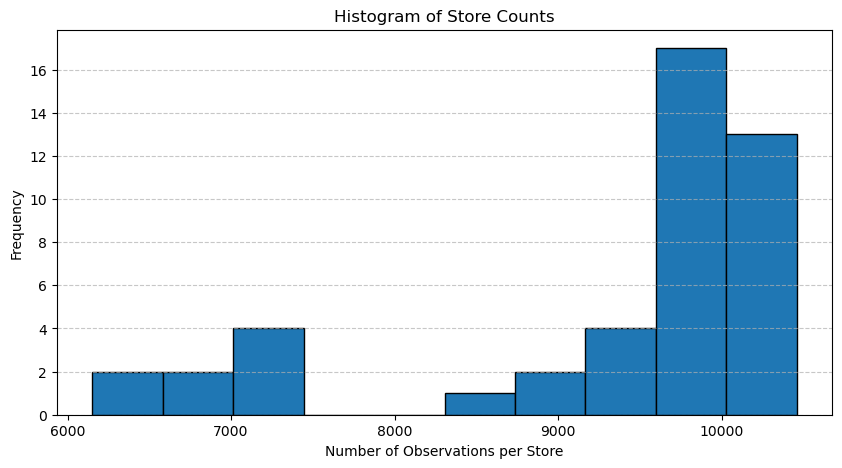

In [52]:
store = df["Store"]
store.unique() #Stores are numbered from 1 to 45 - the dataset contains observations about 45 stores 

store_counts = df["Store"].value_counts().sort_index() #number of observations per store 
print(store_counts.describe()) #each store has at least 6151 observations. the median number of observations is 9807, data is left-skewed

plt.figure(figsize=(10, 5))
plt.hist(store_counts, bins=10, edgecolor="black")
plt.xlabel("Number of Observations per Store")
plt.ylabel("Frequency")
plt.title("Histogram of Store Counts")
plt.grid(axis="y", linestyle="--", alpha=0.7)


#### 1.1.1.2 Type 

The variable type groups stores according to their size. There are three types of store: A,B and C; where A represents the largest store. However we do not have any information about how the size of a store is measured. 

51.1% of observation are from type A stores with average size of 182197.3

38.7% of observation are from type B stores with average size of 101777.6

10.1% of observation are from type C stores with average size of 40536.1


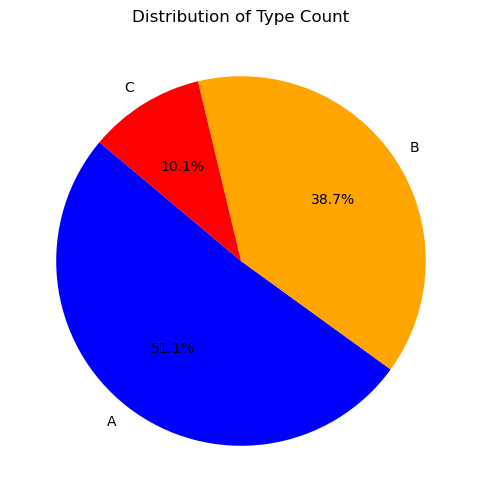

40536.097520777905

In [53]:
type = df["Type"]
type.unique()

type_count =  df["Type"].value_counts().sort_index()

plt.figure(figsize=(8, 6))
plt.pie(type_count, labels=type_count.index, autopct="%1.1f%%", startangle=140, colors=["blue", "orange", "red"])
plt.title("Distribution of Type Count")
plt.show()

df[df["Type"] == "A"]["Size"].mean()
df[df["Type"] == "B"]["Size"].mean()
df[df["Type"] == "C"]["Size"].mean()

#### 1.1.1.3 Department and Categories

There are 81 departments numbered from 1 to 99. Departments are divided into seven categories, each category contains aproximately 12 departments and departments are divided relatively equally among categories

count     7.000000
mean     11.571429
std       2.299068
min       7.000000
25%      11.000000
50%      12.000000
75%      13.000000
max      14.000000
Name: Dept, dtype: float64


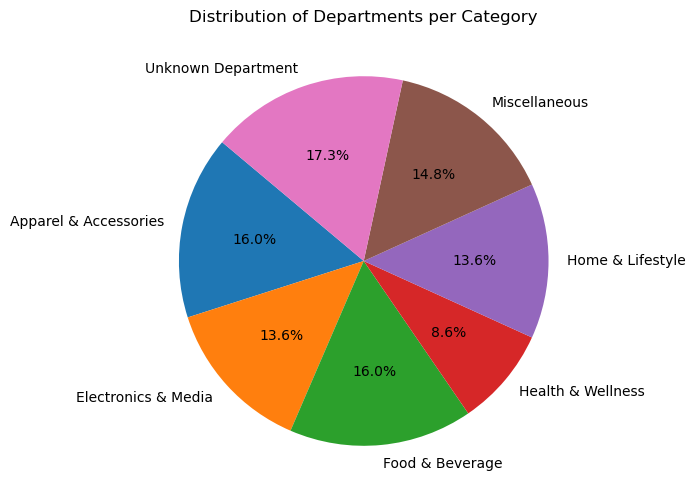

In [54]:
dept = df["Dept"]
dept.nunique()
dept.describe()

#Analysis of number of departments per category
dept_category_counts = df.groupby("Dept_Category")["Dept"].nunique()

print(dept_category_counts.describe())

plt.figure(figsize=(8, 6))
plt.pie(dept_category_counts, labels=dept_category_counts.index, autopct="%1.1f%%", startangle=140)
plt.title("Distribution of Departments per Category")
plt.show()

#### 1.1.1.4 Date (week, month, year)

The dataset represent sales in 143 weeks from 2010-02-05 to 2012-10-26.  For each year, the distribution of occurrences remains consistent across months, with peaks and valleys representing regular intervals (likely months). This suggests that data points are being evenly distributed across each year.

In [55]:
date = df["Date(Date&Time)"]

print("Earliest Date:", date.min())
print("Latest Date:", date.max())
print("\nDate Range:\n", date.describe())

Earliest Date: 2010-02-05 00:00:00
Latest Date: 2012-10-26 00:00:00

Date Range:
 count                  418727
unique                    143
top       2011-12-23 00:00:00
freq                     3019
first     2010-02-05 00:00:00
last      2012-10-26 00:00:00
Name: Date(Date&Time), dtype: object


C:\Users\Greta\AppData\Local\Temp\ipykernel_58588\2094204619.py:5: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  print("\nDate Range:\n", date.describe())


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


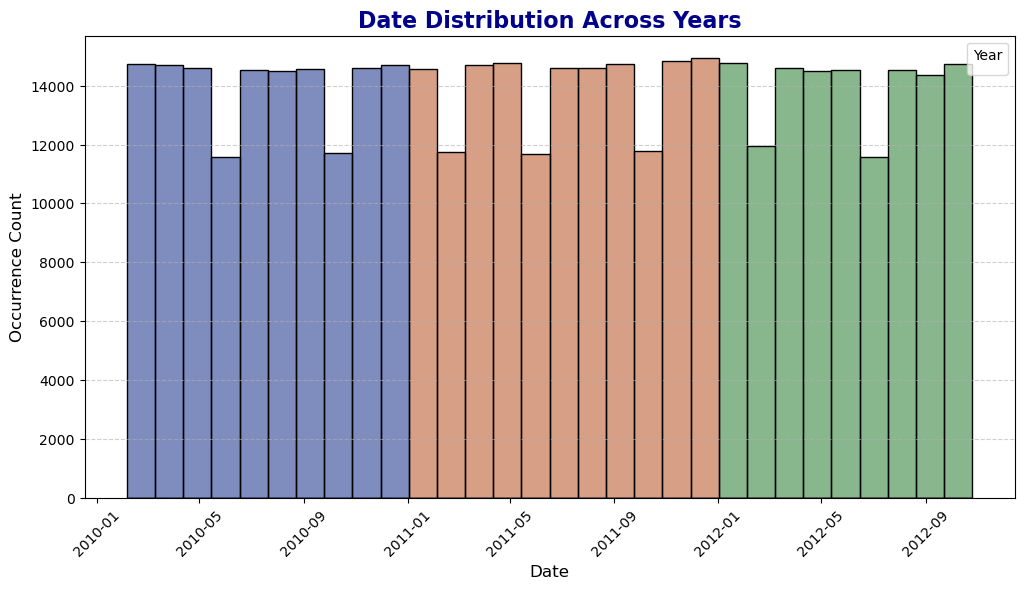

In [56]:
# Date distributions across time 
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="Date(Date&Time)", hue="Year", bins=30, kde=False, palette="dark")
plt.title("Date Distribution Across Years", fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Occurrence Count", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Year")

# Show the plot
plt.show()

#### 1.1.1.5 IsHoliday 

This boolean variable represents whether if a week is an holiday week or not. The holidays considered are: Thanksgiving, Christmas, Super bowl and Labor day. The 7% of observations were recorded during holiday weeks.

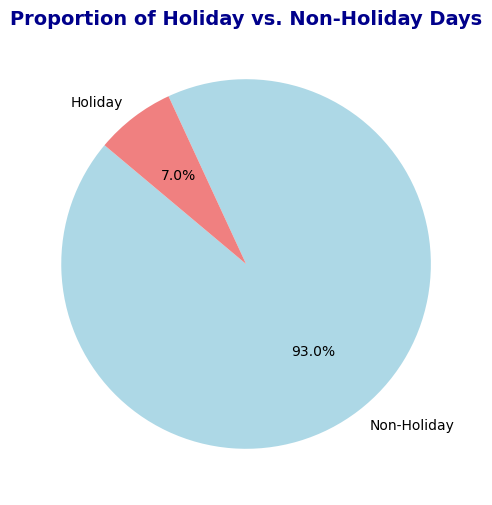

In [57]:
# Count occurrences of each category in IsHoliday
holiday_counts = df["IsHoliday"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(holiday_counts, labels=["Non-Holiday", "Holiday"], autopct="%1.1f%%", colors=["lightblue", "lightcoral"], startangle=140)
plt.title("Proportion of Holiday vs. Non-Holiday Days", fontsize=14, fontweight='bold', color='darkblue')
plt.show()

#### 1.1.1.6 Continuos variables univariate analysis 

In [58]:
print(df.describe()) #to get a general overview of the continuous variables 

                Size   Weekly_Sales    Temperature     Fuel_Price  \
count  418727.000000  418727.000000  418727.000000  418727.000000   
mean   136684.815500   16025.870561      60.052229       3.359306   
std     61010.367641   22725.312252      18.455276       0.458390   
min     34875.000000       0.000000      -2.060000       2.472000   
25%     93638.000000    2116.195000      46.660000       2.931000   
50%    140167.000000    7657.150000      62.060000       3.452000   
75%    202505.000000   20265.010000      74.250000       3.735000   
max    219622.000000  693099.360000     100.140000       4.468000   

                 CPI   Unemployment           Week          Month  \
count  418727.000000  418727.000000  418727.000000  418727.000000   
mean      171.202124       7.961559      25.823711       6.449066   
std        39.158832       1.864314      14.166038       3.246222   
min       126.064000       3.879000       1.000000       1.000000   
25%       132.022667       6.8910

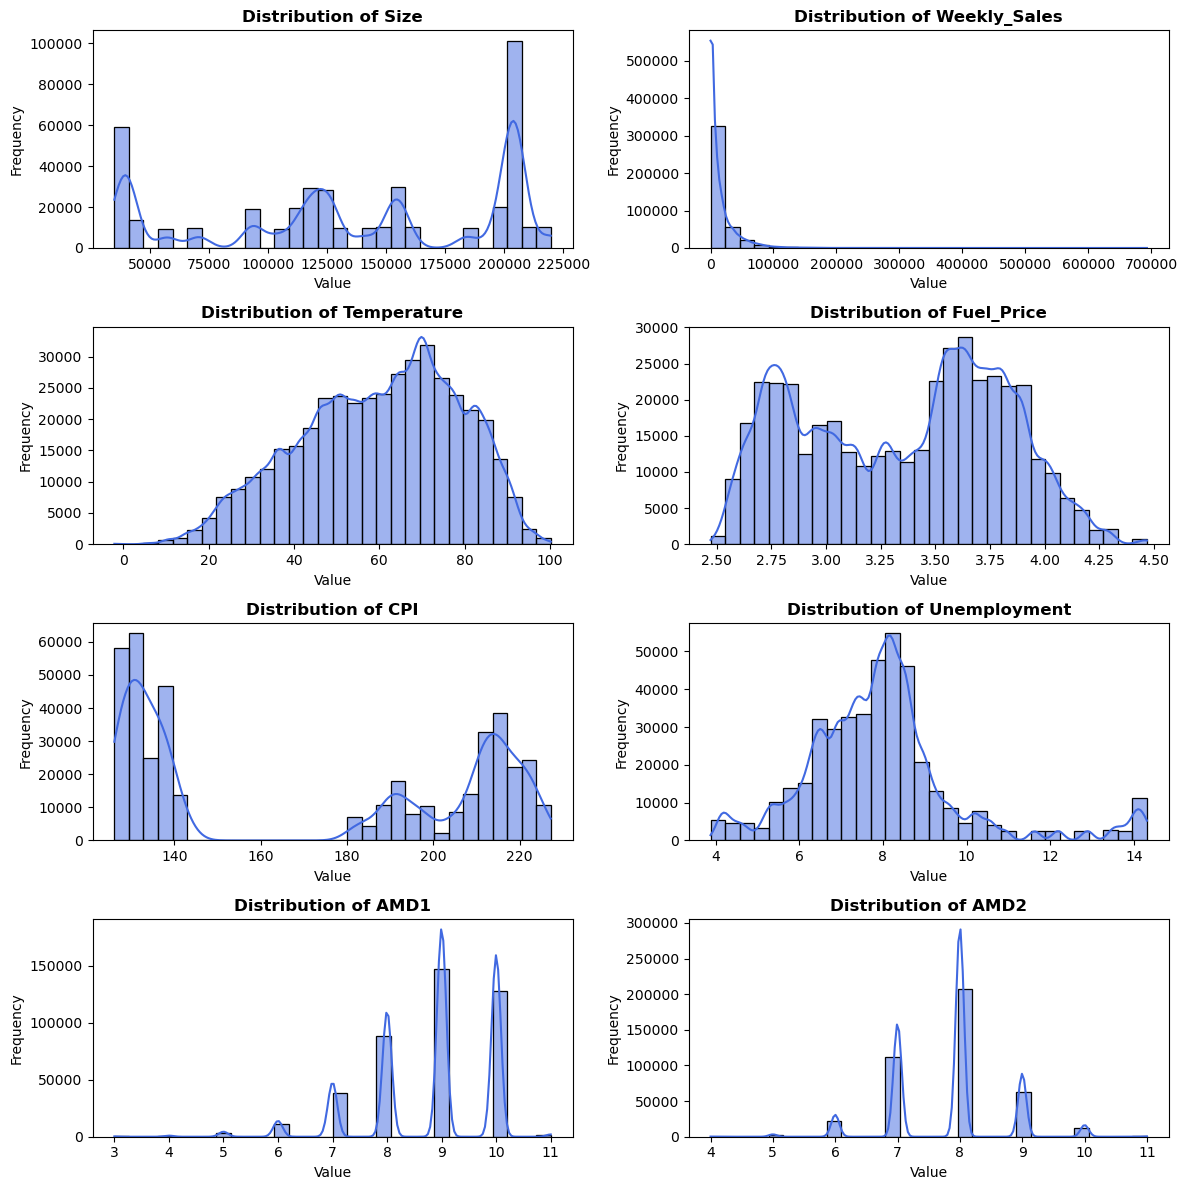

In [59]:
# Select only numerical variables (excluding Year, Week, Month, Date)
vars_to_plot = ["Size", "Weekly_Sales", "Temperature", "Fuel_Price", 
                "CPI", "Unemployment", "AMD1", "AMD2"]

# Create subplots for each variable
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 12))
axes = axes.flatten()
for i, var in enumerate(vars_to_plot):
    sns.histplot(df[var].dropna(), bins=30, kde=True, ax=axes[i], color='royalblue')
    axes[i].set_title(f"Distribution of {var}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Main findings of continuous variables univariate analysis: 

- Size:distribution appears multi-modal, with distinct peaks indicating different store categories (small, medium, large). The presence of multiple clusters suggests that store sizes are not uniformly distributed but fall into predefined categories.

- Weekly Sales: the distribution is highly right-skewed, meaning most stores have relatively low weekly sales, while a few outliers have extremely high sales. The peak near zero suggests some stores may report very low or even zero sales for certain periods.

- Temperature: the histogram exhibits a normal-like distribution, which is expected for temperature data.

- Fuel Price: fuel prices fluctuate within a few key pricing ranges. 

- CPI (Consumer Price Index): the histogram has a bimodal structure, indicating a shift in inflation or cost-of-living over time.

- Unemployment: the distribution is right-skewed, showing that most regions have moderate unemployment rates, while some experience significantly higher values.

- AMD1 and AMD2: both distributions show distinct integer values, indicating that these variables have undergone a log transformation.

### 1.1.2 Bivariate Analysis 

Correlation Matrix - main insights: 
- Markdowns are positively correlated with size, in fact larger stores tend to make promotions more frequently than smaller ones.
- Markdowns are negatively correlated with fuel price. 
- Unemployment and CPI are negatively correlated, as we could expect for the nature of this variables.

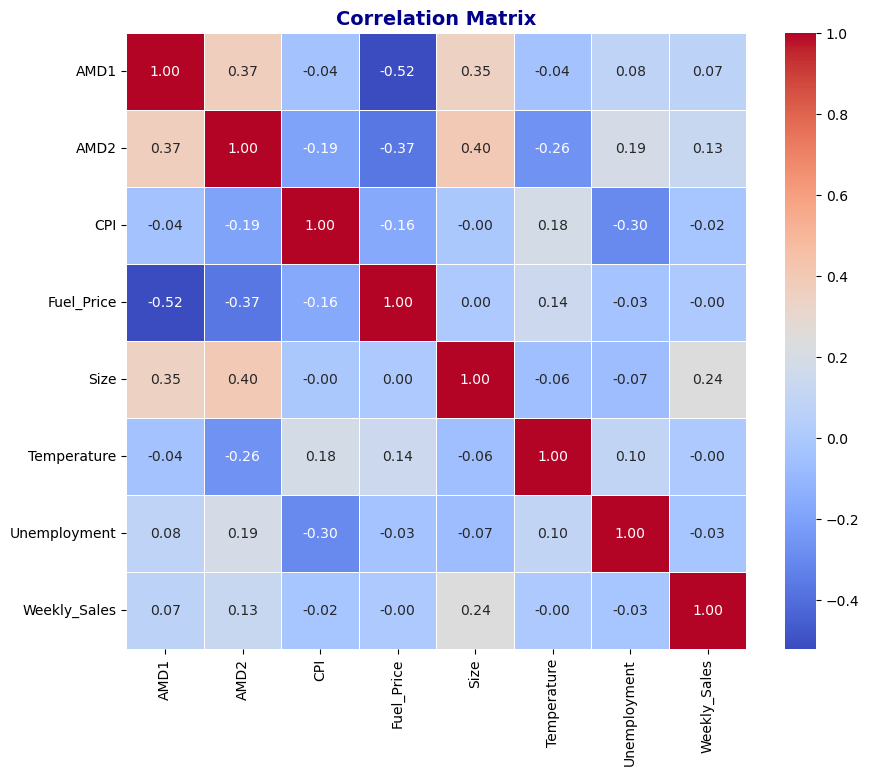

In [60]:
vars_to_include = df.select_dtypes(include=["number"]).columns.difference(["Year", "Month", "Week"])

# Compute correlation matrix
correlation_matrix = df[vars_to_include].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14, fontweight="bold", color="darkblue")
plt.show()

### 1.1.3 Weekly sales over time

Weekly sales over time 

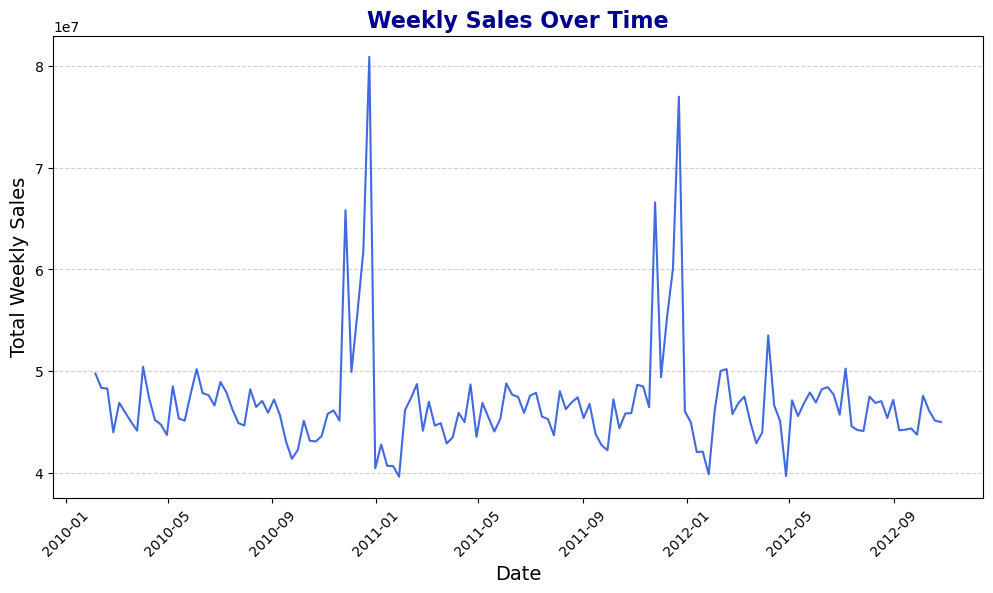

In [61]:
weekly_sales_over_time = df.groupby("Date(Date&Time)")["Weekly_Sales"].sum().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=weekly_sales_over_time, x="Date(Date&Time)", y="Weekly_Sales", linestyle="-", color="royalblue")
plt.title("Weekly Sales Over Time", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Date", fontsize=14)
plt.ylabel("Total Weekly Sales", fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

Average weekly sales over the months 

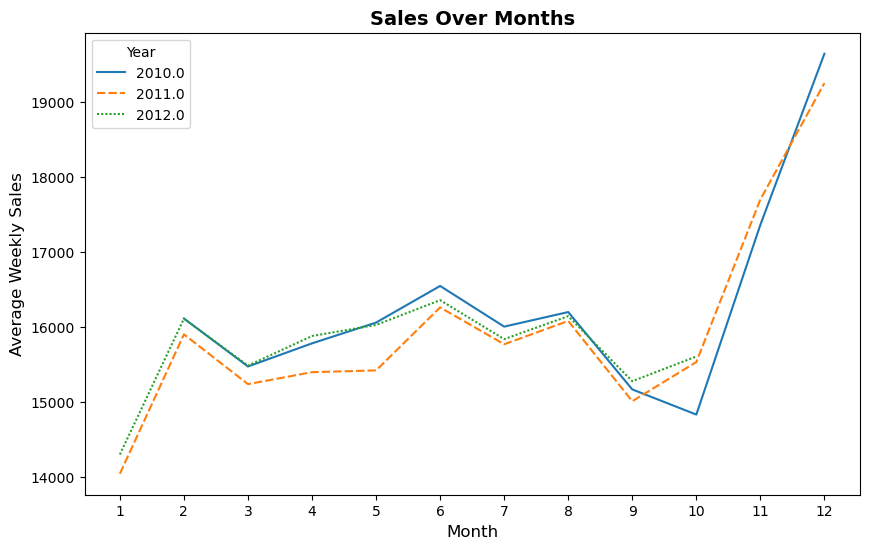

In [62]:
monthly_sales = df.groupby(["Year", "Month"])["Weekly_Sales"].mean().reset_index() 
sales_pivot = monthly_sales.pivot(index="Month", columns="Year", values="Weekly_Sales") #pivot for plotting 

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=sales_pivot)
plt.title("Sales Over Months", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Weekly Sales", fontsize=12)
plt.xticks(range(1, 13)) 
plt.legend(title="Year")
plt.show()


Weekly sales over the weeks

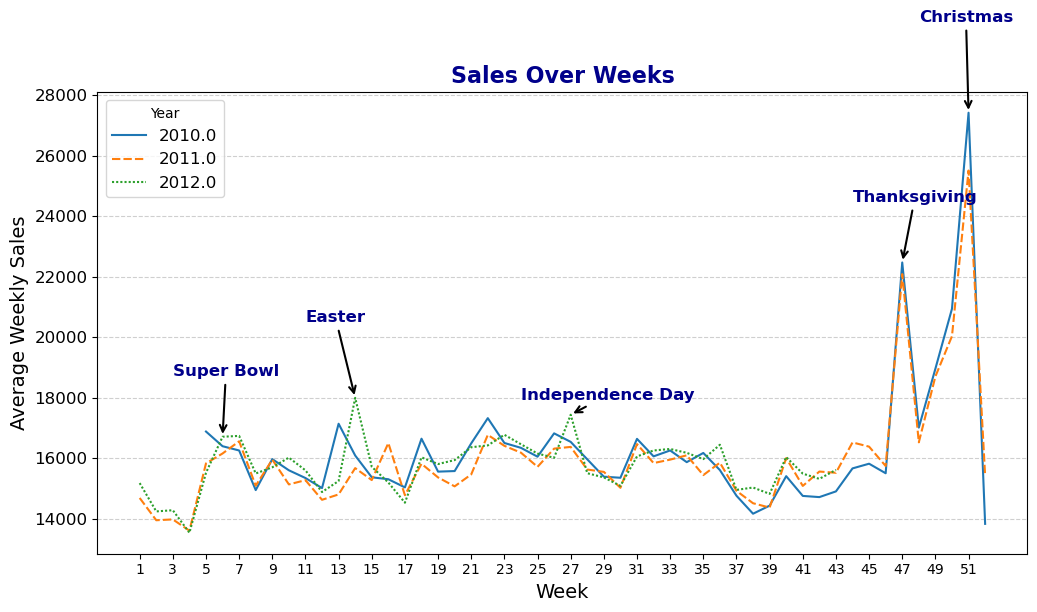

In [63]:
weekly_sales = df.groupby(["Year", "Week"])["Weekly_Sales"].mean().reset_index()
sales_pivot = weekly_sales.pivot(index="Week", columns="Year", values="Weekly_Sales")

# Plot the trends
plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_pivot, linestyle="-")

holidays = {
    "Easter": (14, 2500),  
    "Super Bowl": (6, 2000),  
    "Independence Day": (27, 500),  
    "Thanksgiving": (47, 2000),  
    "Christmas": (51, 3000) 
}

for holiday, (week, shift) in holidays.items():
    y_pos = sales_pivot.loc[week].max()  # Find the highest value at that week
    plt.annotate(holiday, xy=(week, y_pos), xytext=(week - 3, y_pos + shift),
                 arrowprops=dict(facecolor="black", arrowstyle="->", lw=1.5),
                 fontsize=12, color="darkblue", fontweight="bold")

plt.title("Sales Over Weeks", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Week", fontsize=14)
plt.ylabel("Average Weekly Sales", fontsize=14)
plt.xticks(range(1, 53, 2)) 
plt.yticks(fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Year", fontsize=12)
plt.show()

After a visual anlysis of the behavior of weekly sales over the years we notice that: 
- The overall trend of data appears to be relatively stable over time 
- The graphs show seasonality with significant sales spikes occurring at regular intervals, likely corresponding to holiday periods. A formal analysis should be conducted to confirm seasonal patterns. 
- Even if sales are relatively stable over time, the highest levels of sales are registered from October to December, and sales tend to peak during holiday weeks. 

In the next steps we'll evalutate non-stationarity and seasonality more in depth. 

Identifying non stationarity 
- run-sequence plots 
- summary statistics mean and variance through time - split data in chunk and compute mean, variance 
- histogram plot (statitionary data follows normality )
- augmented dickey-fuller test : Se il periodo di osservazione è relativamente corto, il test ADF potrebbe avere più probabilità di rilevare stazionarietà spurie.

In [64]:
#

y = df["Weekly_Sales"]

# Perform the Augmented Dickey-Fuller test
adf_test = adfuller(y, autolag='AIC')

# Print results
print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])
print("Critical Values:")
for key, value in adf_test[4].items():
    print(f"\t{key}: {value}")

# Interpretation
if adf_test[1] < 0.05:
    print("The time series is stationary (reject H0).")
else:
    print("The time series is non-stationary (fail to reject H0).")

ADF Statistic: -36.54670532682099
p-value: 0.0
Critical Values:
	1%: -3.4303656207736593
	5%: -2.8615469041951367
	10%: -2.5667736748513845
The time series is stationary (reject H0).


<Figure size 1000x500 with 0 Axes>

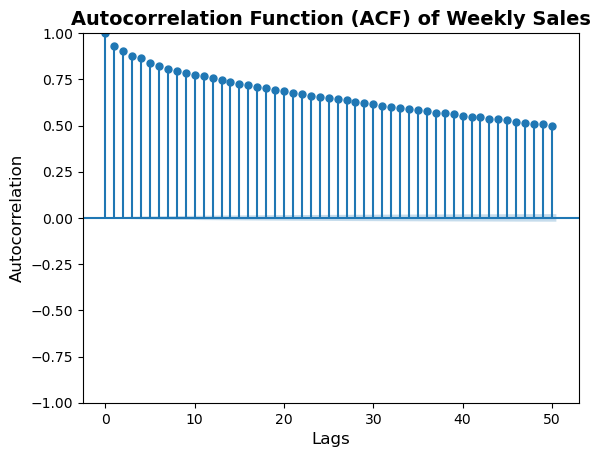

In [65]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot the Autocorrelation Function (ACF)
plt.figure(figsize=(10, 5))
plot_acf(df['Weekly_Sales'], lags=50)  # Adjust lags as needed
plt.xlabel("Lags", fontsize=12)
plt.ylabel("Autocorrelation", fontsize=12)
plt.title("Autocorrelation Function (ACF) of Weekly Sales", fontsize=14, fontweight='bold')
plt.show() 

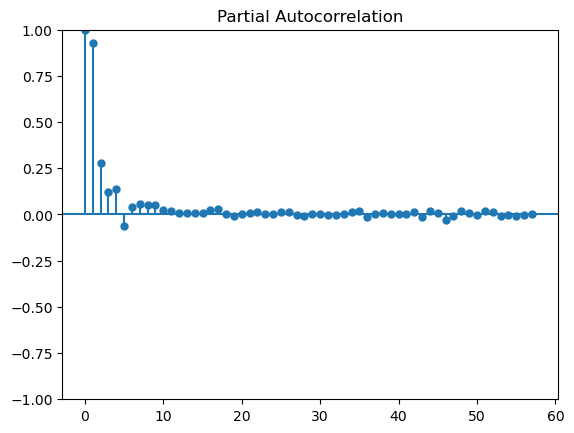

In [9]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

# Plotta PACF sulla serie differenziata (se d=1)
plot_pacf(df['Weekly_Sales'].dropna())
plt.show()



The Autocorrelation Function (ACF) plot shows slow decay over time.
This indicates strong autocorrelation across multiple lags, which is often a sign of non-stationarity and a possible seasonal pattern.
However, there are no clear periodic peaks at specific lags (e.g., every 7, 30, or 52 lags), suggesting that if seasonality exists, it may not be perfectly regular.

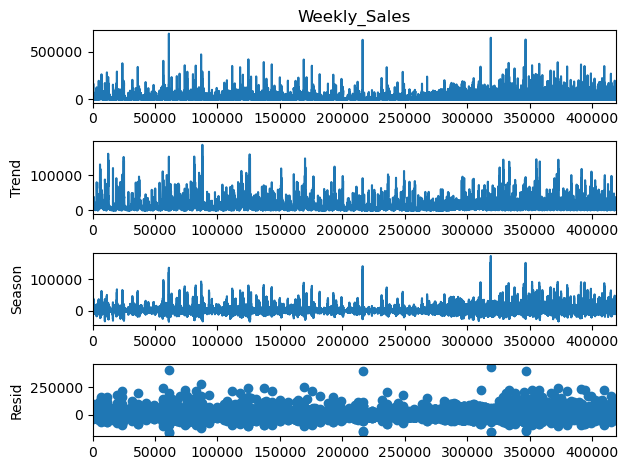

In [66]:
from statsmodels.tsa.seasonal import STL #STL decomposition 

stl = STL(df['Weekly_Sales'], period=52)
result = stl.fit()
result.plot()
plt.show()


<Figure size 1000x600 with 0 Axes>

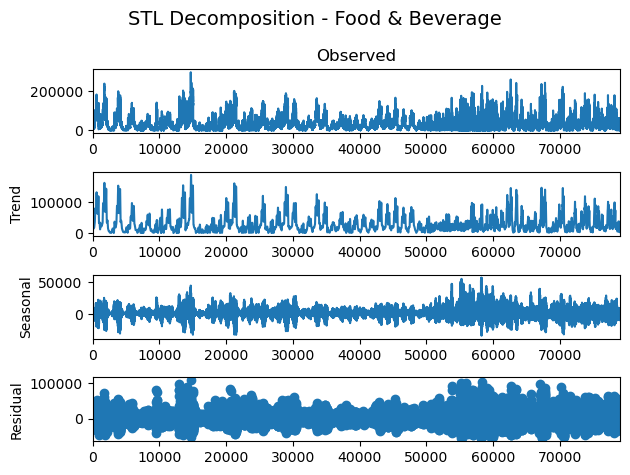

<Figure size 1000x600 with 0 Axes>

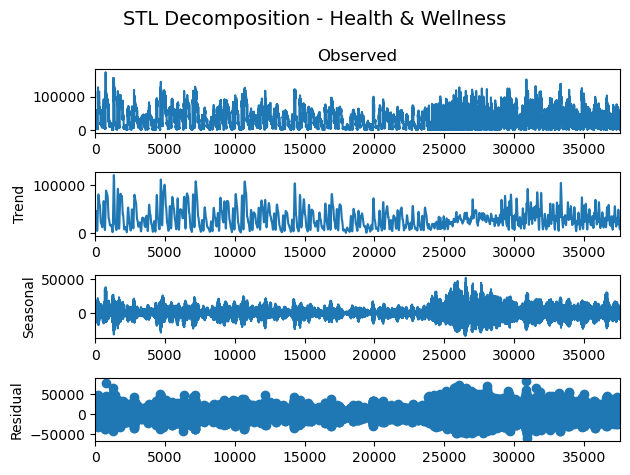

<Figure size 1000x600 with 0 Axes>

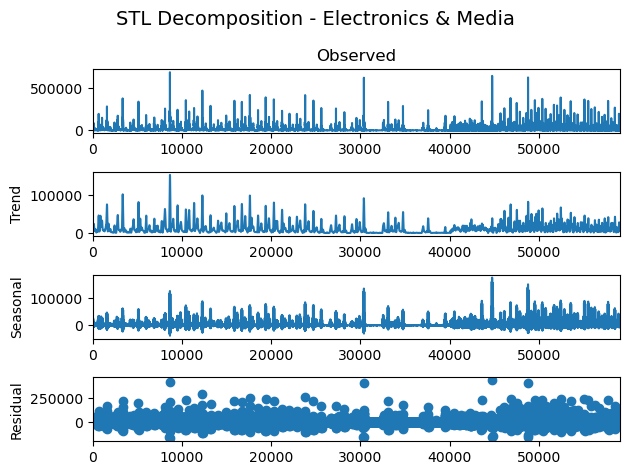

<Figure size 1000x600 with 0 Axes>

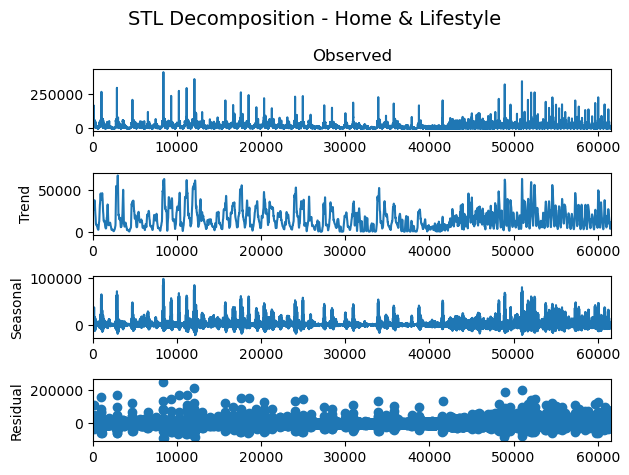

<Figure size 1000x600 with 0 Axes>

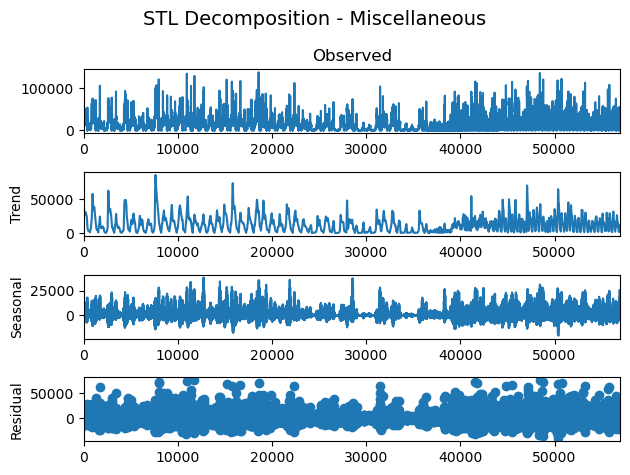

<Figure size 1000x600 with 0 Axes>

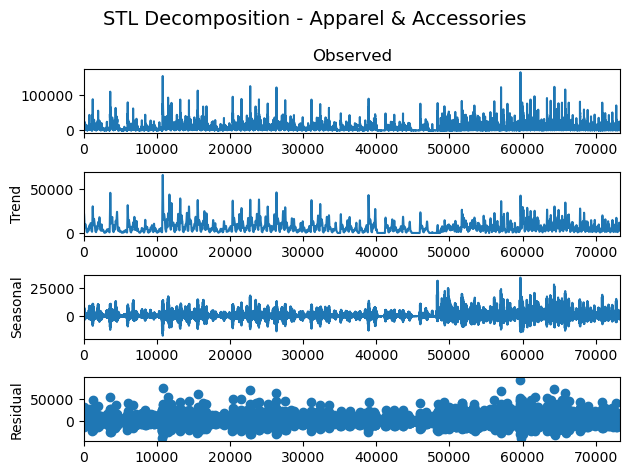

<Figure size 1000x600 with 0 Axes>

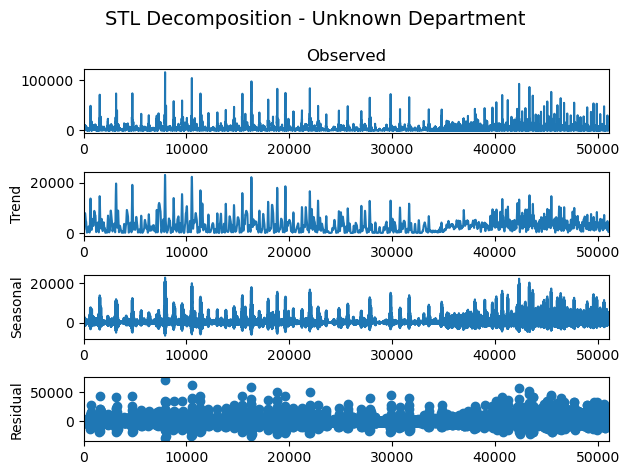

In [ ]:

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# Assicurati che il dataframe sia già aggregato per Week e Category
# df ha queste colonne: ['Week', 'Category', 'Weekly_Sales']
# e 'Week' sia datetime

categories = df['Dept_Category'].unique()

for cat in categories:
    df_cat = df[df['Dept_Category'] == cat]
    
    # Assicurati che la serie sia ordinata temporalmente
    sales_series = df_cat['Weekly_Sales'].values
    
    # Applica STL con period=52 (settimanale su base annuale)
    stl = STL(sales_series, period=52)
    result = stl.fit()
    
    # Plot dei componenti
    plt.figure(figsize=(10, 6))
    result.plot()
    plt.suptitle(f'STL Decomposition - {cat}', fontsize=14)
    plt.tight_layout()
    plt.show()


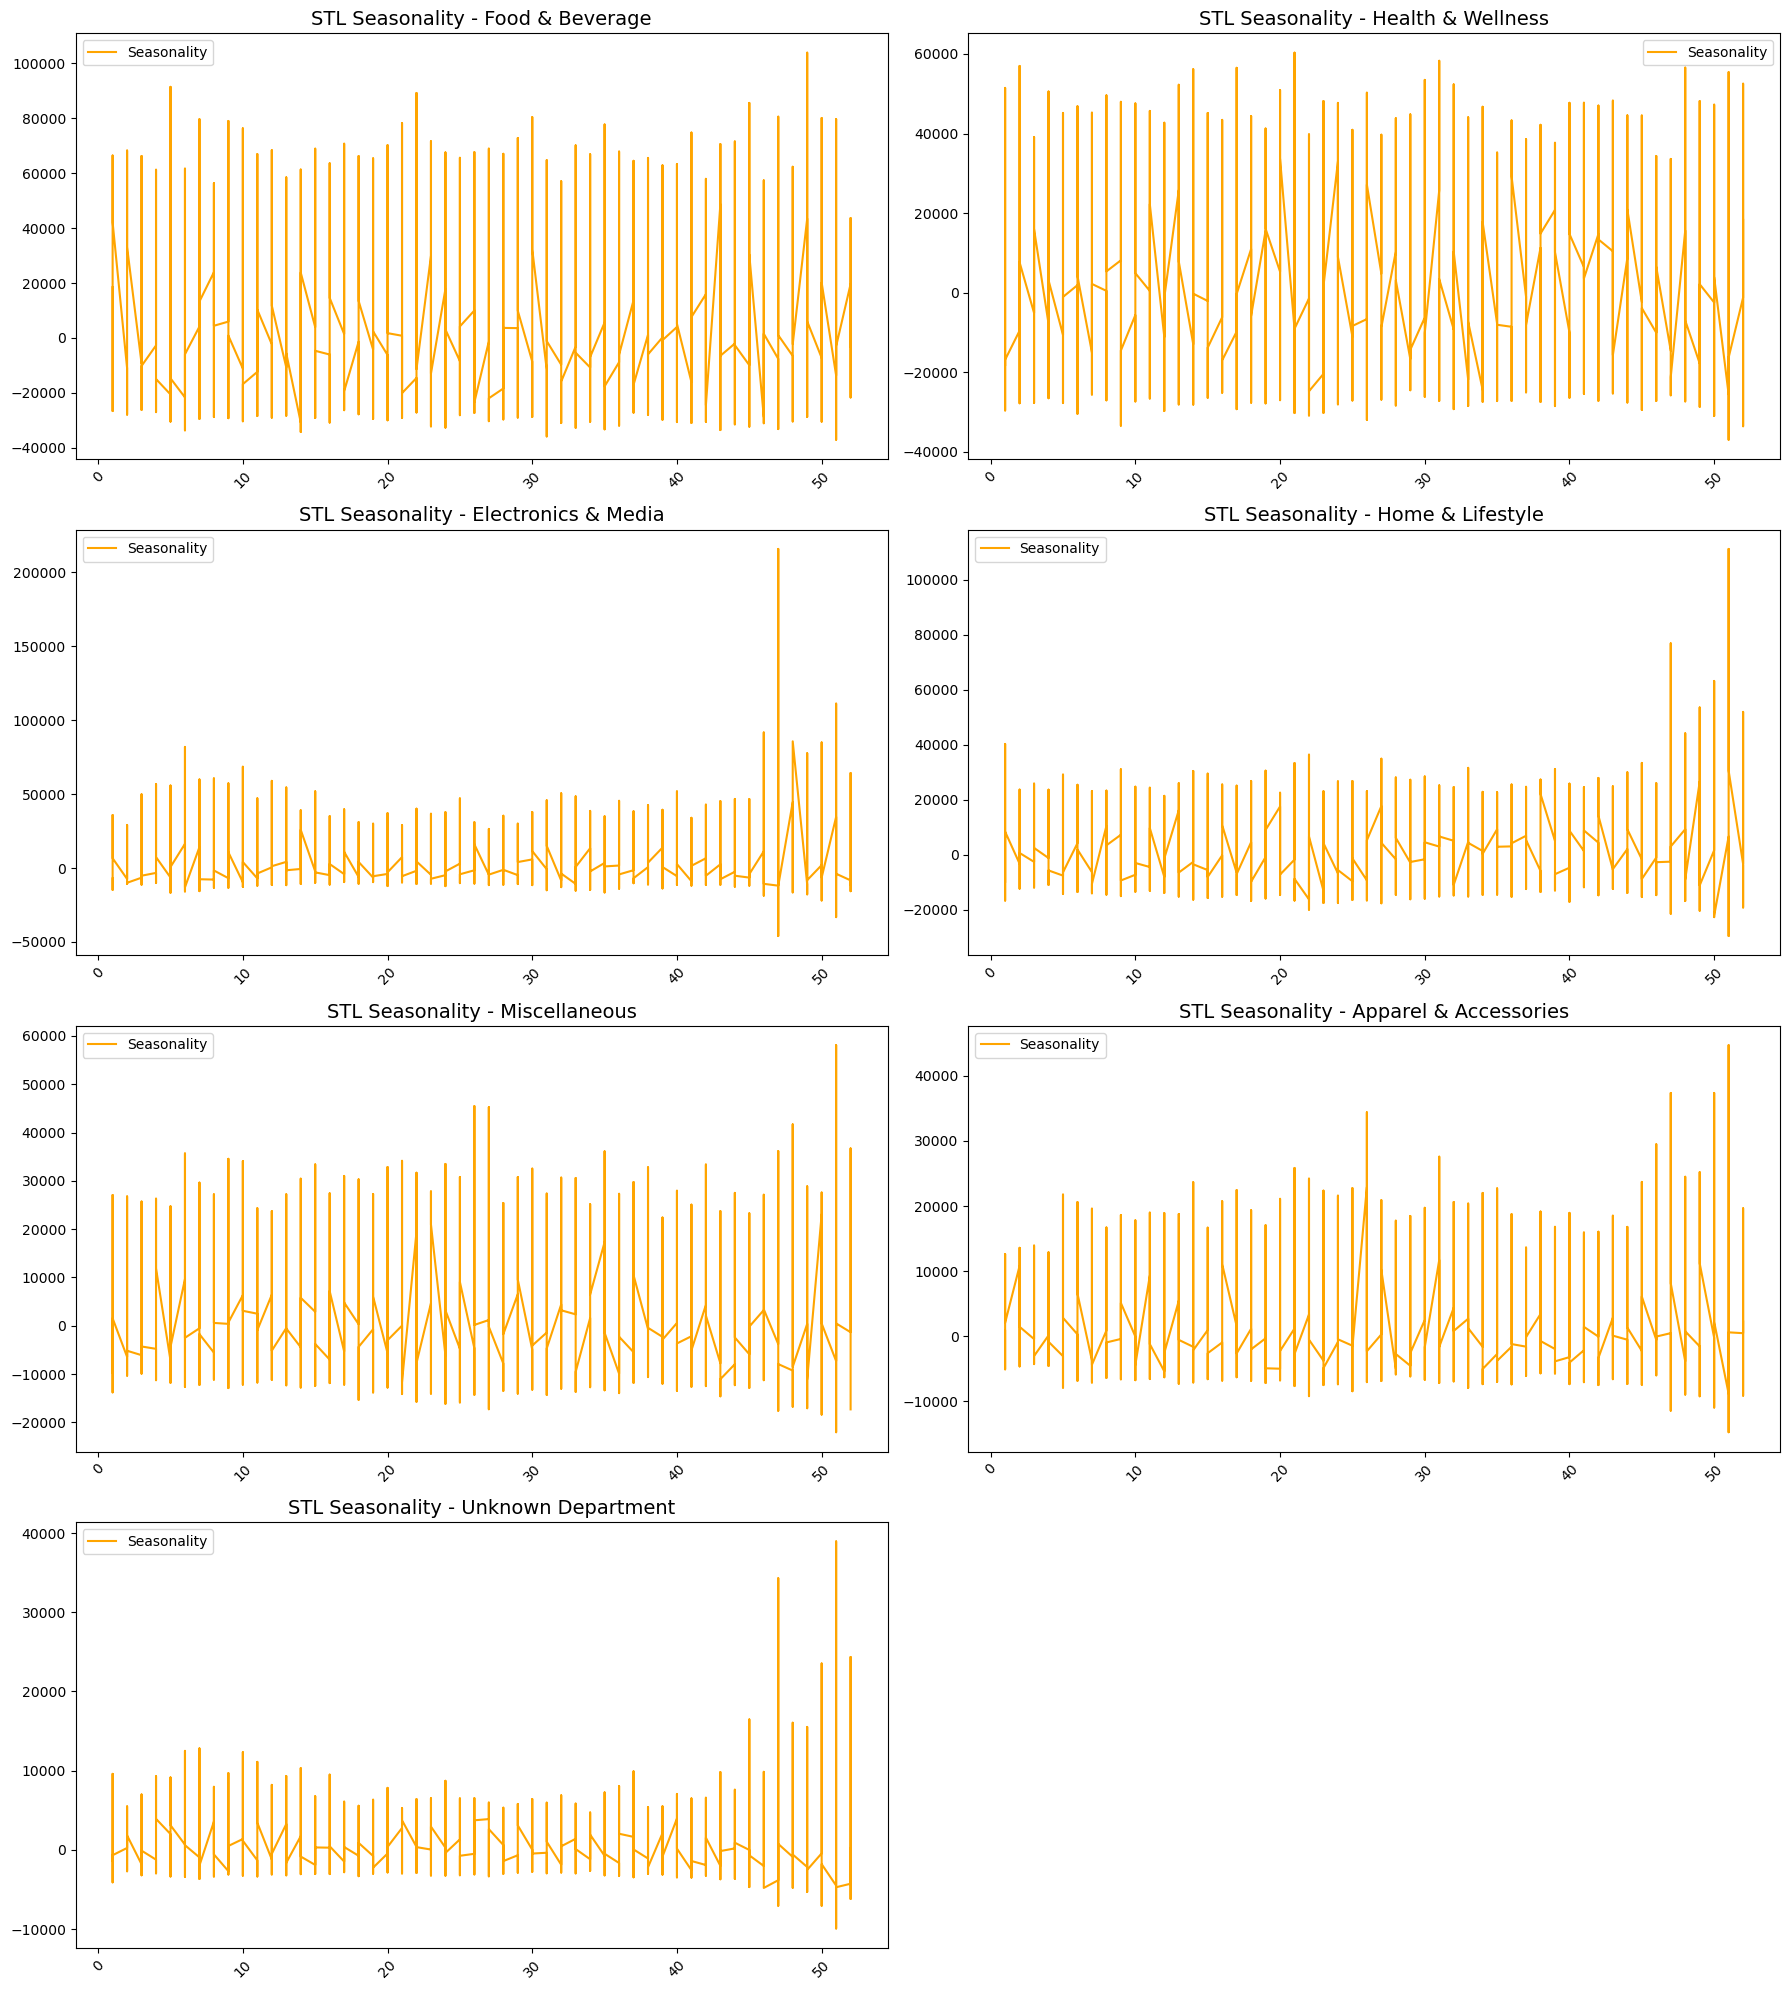

In [34]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# Assicurati che il dataframe sia già aggregato per Week e Category
categories = df['Dept_Category'].unique()

# Creo una griglia 4x2 per 7 categorie (+ 1 spazio vuoto)
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()  # così itero facilmente

for i, cat in enumerate(categories):
    df_cat = df[df['Dept_Category'] == cat].sort_values('Week')
    sales_series = df_cat['Weekly_Sales'].values

    # STL decomposition
    stl = STL(sales_series, period=52)
    result = stl.fit()

    # Plot della Seasonality
    axes[i].plot(df_cat['Week'], result.seasonal, label='Seasonality', color='orange')
    axes[i].set_title(f'STL Seasonality - {cat}', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend()

# Nascondi eventuali assi vuoti
for j in range(len(categories), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



# 2. FORECASTING METHODS 

## 2.1 EXPONENTIAL SMOOTHING 

### 2.1.1 SINGLE EXPONENTIAL SMOOTHING 


 Overall Forecast Error Metrics (Holt’s Model - Out-of-Sample):
  Metric        Value
0    MAE  2619.164706
1   RMSE  3190.431893

 Store-Department Level Forecast Metrics (Out-of-Sample):
   Store  Department           MAE          RMSE
0    1.0           1  38678.258120  38886.402678
1    1.0           2   2102.703381   2488.881641
2    1.0           3   7172.181449  12700.603726
3    1.0           4   2115.123962   2575.068911
4    1.0           5   6869.947141   7529.817586


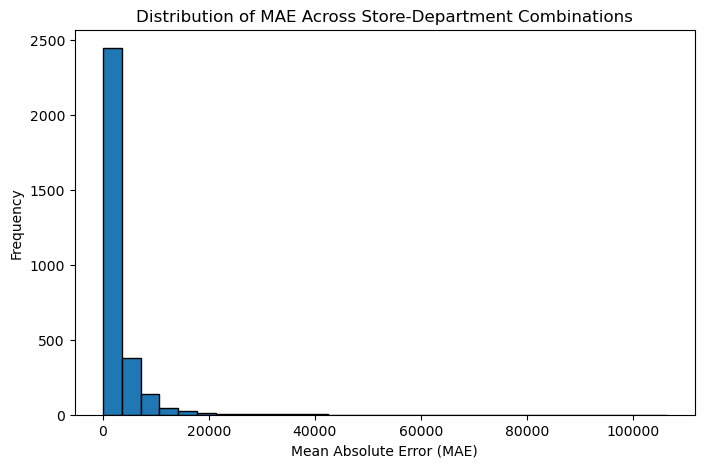

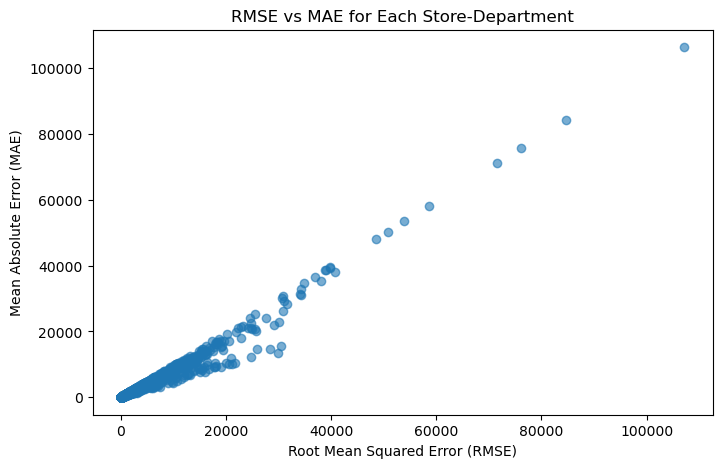

In [59]:
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

df = df[df["Weekly_Sales"] > 0]

evaluation_results = []

grouped = df.groupby(['Store', 'Dept'])

for (store, department), group in grouped:
    try:
        if len(group) < 20:
            continue

        group = group.sort_values('Date(Date&Time)').reset_index(drop=True)

        train_size = int(0.8 * len(group))
        train, test = group.iloc[:train_size], group.iloc[train_size:]

        model = ExponentialSmoothing(
            train['Weekly_Sales'],
            trend=None,
            seasonal=None
        )
        fit = model.fit()

        forecast = fit.forecast(len(test))

        mae = mean_absolute_error(test['Weekly_Sales'], forecast)
        rmse = np.sqrt(mean_squared_error(test['Weekly_Sales'], forecast))

        evaluation_results.append([store, department, mae, rmse])

    except Exception as e:
        print(f"Error processing Store {store}, Department {department}: {e}")
        continue

metrics_df = pd.DataFrame(evaluation_results, columns=['Store', 'Department', 'MAE', 'RMSE'])

overall_mae = metrics_df['MAE'].mean()
overall_rmse = metrics_df['RMSE'].mean()

overall_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [overall_mae, overall_rmse]
})

print("\n Overall Forecast Error Metrics (Holt’s Model - Out-of-Sample):")
print(overall_metrics_df)

print("\n Store-Department Level Forecast Metrics (Out-of-Sample):")
print(metrics_df.head())

plt.figure(figsize=(8, 5))
plt.hist(metrics_df['MAE'], bins=30, edgecolor='black')
plt.xlabel('Mean Absolute Error (MAE)')
plt.ylabel('Frequency')
plt.title('Distribution of MAE Across Store-Department Combinations')
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(metrics_df['RMSE'], metrics_df['MAE'], alpha=0.6)
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('RMSE vs MAE for Each Store-Department')
plt.show()



Overall Forecast Error Metrics (Holt’s Model - Store-Category Level):
  Metric         Value
0    MAE  14442.401463
1   RMSE  17321.352757

Store-Category Level Forecast Metrics (Sample):
   Store               Category           MAE          RMSE
0    1.0  Apparel & Accessories  16550.692693  19017.632367
1    1.0    Electronics & Media  19102.683813  20746.704253
2    1.0        Food & Beverage  39486.897959  47412.278788
3    1.0      Health & Wellness  19735.019932  21804.679475
4    1.0       Home & Lifestyle  40866.968284  46419.817216


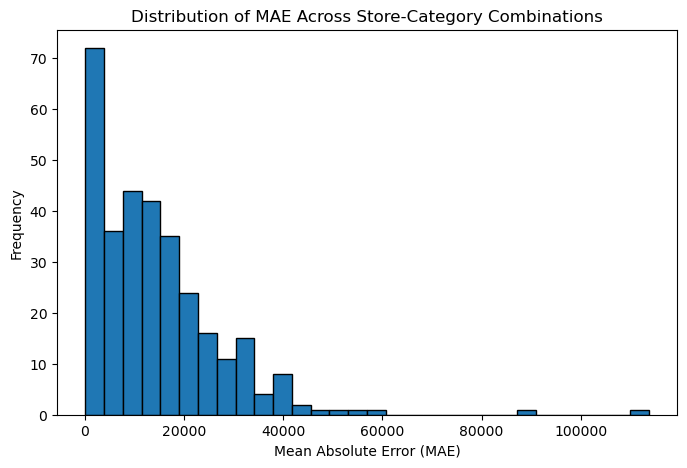

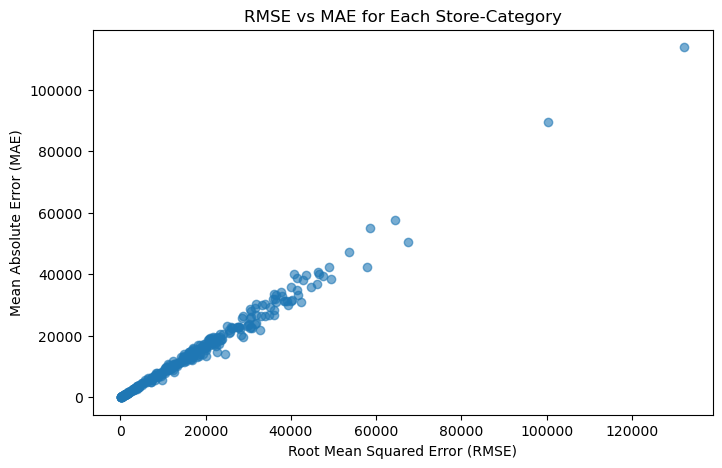

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import warnings

warnings.filterwarnings("ignore")

df = df[df["Weekly_Sales"] > 0]
df['Date(Date&Time)'] = pd.to_datetime(df['Date(Date&Time)'])

weekly_agg = df.groupby(['Store', 'Dept_Category', 'Date(Date&Time)'])['Weekly_Sales'].sum().reset_index()

evaluation_results = []

grouped = weekly_agg.groupby(['Store', 'Dept_Category'])

for (store, category), group in grouped:
    try:
        group = group.sort_values('Date(Date&Time)').reset_index(drop=True)
        if len(group) < 20:
            continue

        train_size = int(0.8 * len(group))
        train, test = group.iloc[:train_size], group.iloc[train_size:]

        model = ExponentialSmoothing(
            train['Weekly_Sales'],
            trend=None,
            seasonal=None
        )
        fit = model.fit()

        forecast = fit.forecast(len(test))

        mae = mean_absolute_error(test['Weekly_Sales'], forecast)
        rmse = np.sqrt(mean_squared_error(test['Weekly_Sales'], forecast))

        evaluation_results.append([store, category, mae, rmse])

    except Exception as e:
        print(f"Error processing Store {store}, Category {category}: {e}")
        continue

metrics_df = pd.DataFrame(evaluation_results, columns=['Store', 'Category', 'MAE', 'RMSE'])

overall_mae = metrics_df['MAE'].mean()
overall_rmse = metrics_df['RMSE'].mean()

overall_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [overall_mae, overall_rmse]
})

print("\nOverall Forecast Error Metrics (Holt’s Model - Store-Category Level):")
print(overall_metrics_df)

print("\nStore-Category Level Forecast Metrics (Sample):")
print(metrics_df.head())

plt.figure(figsize=(8, 5))
plt.hist(metrics_df['MAE'].dropna(), bins=30, edgecolor='black')
plt.xlabel('Mean Absolute Error (MAE)')
plt.ylabel('Frequency')
plt.title('Distribution of MAE Across Store-Category Combinations')
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(metrics_df['RMSE'], metrics_df['MAE'], alpha=0.6)
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('RMSE vs MAE for Each Store-Category')
plt.show()


### 2.1.2 DOUBLE EXPONENTIAL SMOOTHING 

Forecasting sales with double exponential smoothing (weekly sales forecasted in store's departments)


Overall Forecast Error Metrics (Double Exponential Smoothing - Out-of-Sample):
  Metric        Value
0    MAE  4114.652160
1   RMSE  4854.796839

Store-Department Level Forecast Metrics (Out-of-Sample):
   Store  Department           MAE          RMSE
0    1.0           1  54138.802835  54863.812347
1    1.0           2   4040.932978   4737.914554
2    1.0           3  10293.376277  15761.813830
3    1.0           4   2582.397108   3061.075487
4    1.0           5   4538.673984   5386.768461


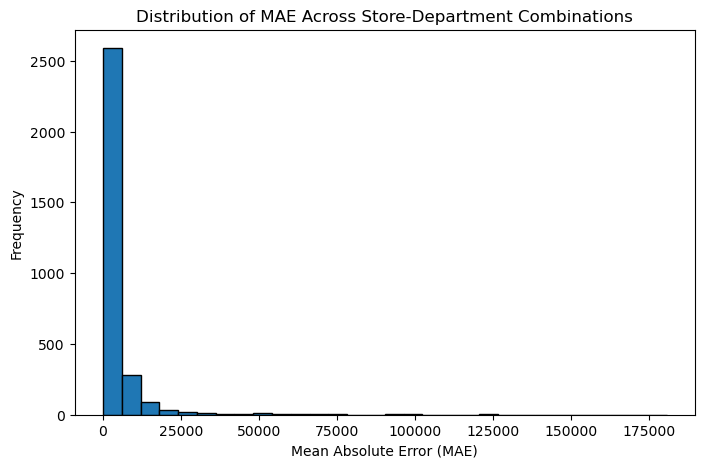

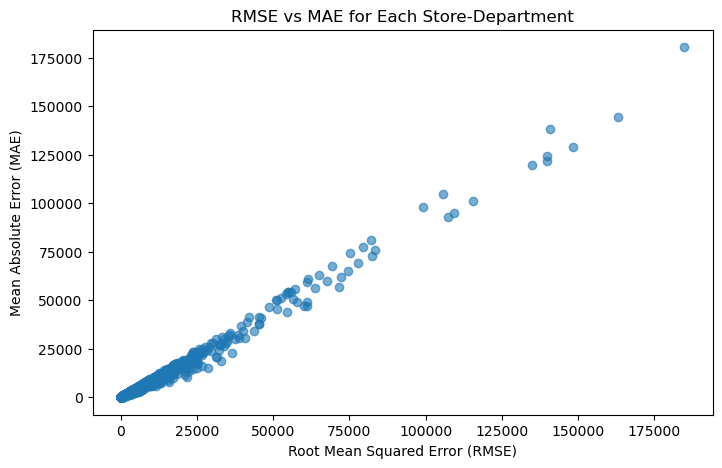

In [65]:

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings("ignore")

df = df[df["Weekly_Sales"] > 0]

evaluation_results = []

grouped = df.groupby(['Store', 'Dept'])

for (store, department), group in grouped:
    try:
        if len(group) < 20: 
            continue

        group = group.sort_values('Date(Date&Time)').reset_index(drop=True)

        train_size = int(0.8 * len(group))
        train, test = group.iloc[:train_size], group.iloc[train_size:]

        model = ExponentialSmoothing(
            train['Weekly_Sales'],
            trend='add',
            seasonal=None
        )
        fit = model.fit()

        forecast = fit.forecast(len(test))

        mae = mean_absolute_error(test['Weekly_Sales'], forecast)
        rmse = np.sqrt(mean_squared_error(test['Weekly_Sales'], forecast))

        evaluation_results.append([store, department, mae, rmse])

    except Exception as e:
        print(f"Error processing Store {store}, Department {department}: {e}")
        continue

metrics_df = pd.DataFrame(evaluation_results, columns=['Store', 'Department', 'MAE', 'RMSE'])

overall_mae = metrics_df['MAE'].mean()
overall_rmse = metrics_df['RMSE'].mean()

overall_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [overall_mae, overall_rmse]
})

print("\nOverall Forecast Error Metrics (Double Exponential Smoothing - Out-of-Sample):")
print(overall_metrics_df)

print("\nStore-Department Level Forecast Metrics (Out-of-Sample):")
print(metrics_df.head())

plt.figure(figsize=(8, 5))
plt.hist(metrics_df['MAE'], bins=30, edgecolor='black')
plt.xlabel('Mean Absolute Error (MAE)')
plt.ylabel('Frequency')
plt.title('Distribution of MAE Across Store-Department Combinations')
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(metrics_df['RMSE'], metrics_df['MAE'], alpha=0.6)
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('RMSE vs MAE for Each Store-Department')
plt.show()



Overall Forecast Error Metrics (Holt’s Model - Store-Category Level):
  Metric         Value
0    MAE  19592.995302
1   RMSE  23267.502428

Store-Category Level Forecast Metrics (Sample):
   Store               Category           MAE          RMSE
0    1.0  Apparel & Accessories  14824.015914  17145.988316
1    1.0    Electronics & Media  15130.383543  17949.026217
2    1.0        Food & Beverage  50728.048747  62800.067395
3    1.0      Health & Wellness  37807.510391  40487.455024
4    1.0       Home & Lifestyle  62010.774110  69877.768114


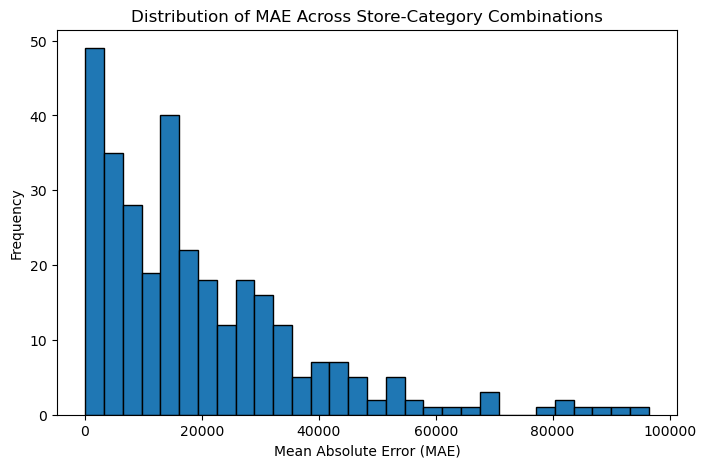

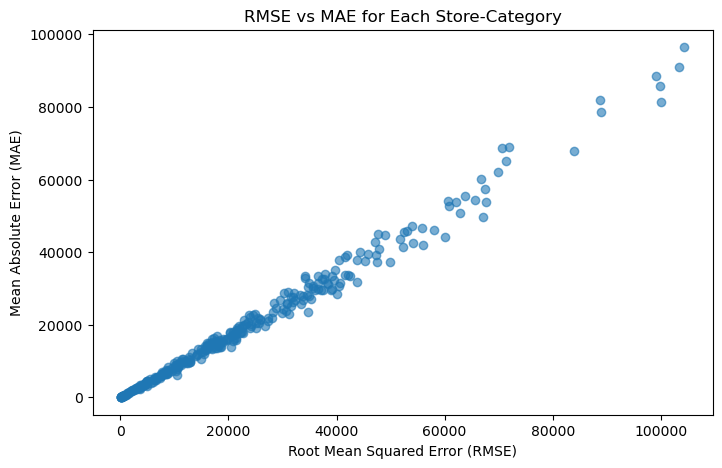

In [47]:
#CATEGORY
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import warnings

warnings.filterwarnings("ignore")

df = df[df["Weekly_Sales"] > 0]
df['Date(Date&Time)'] = pd.to_datetime(df['Date(Date&Time)'])

weekly_agg = df.groupby(['Store', 'Dept_Category', 'Date(Date&Time)'])['Weekly_Sales'].sum().reset_index()

evaluation_results = []

grouped = weekly_agg.groupby(['Store', 'Dept_Category'])

for (store, category), group in grouped:
    try:
        group = group.sort_values('Date(Date&Time)').reset_index(drop=True)
        if len(group) < 10:
            continue

        train_size = int(0.8 * len(group))
        train, test = group.iloc[:train_size], group.iloc[train_size:]

        model = ExponentialSmoothing(
            train['Weekly_Sales'],
            trend='add',
            seasonal=None
        )
        fit = model.fit()

        forecast = fit.forecast(len(test))

        mae = mean_absolute_error(test['Weekly_Sales'], forecast)
        rmse = np.sqrt(mean_squared_error(test['Weekly_Sales'], forecast))

        evaluation_results.append([store, category, mae, rmse])

    except Exception as e:
        print(f"Error processing Store {store}, Category {category}: {e}")
        continue

metrics_df = pd.DataFrame(evaluation_results, columns=['Store', 'Category', 'MAE', 'RMSE'])

overall_mae = metrics_df['MAE'].mean()
overall_rmse = metrics_df['RMSE'].mean()

overall_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [overall_mae, overall_rmse]
})

print("\nOverall Forecast Error Metrics (Holt’s Model - Store-Category Level):")
print(overall_metrics_df)

print("\nStore-Category Level Forecast Metrics (Sample):")
print(metrics_df.head())

plt.figure(figsize=(8, 5))
plt.hist(metrics_df['MAE'].dropna(), bins=30, edgecolor='black')
plt.xlabel('Mean Absolute Error (MAE)')
plt.ylabel('Frequency')
plt.title('Distribution of MAE Across Store-Category Combinations')
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(metrics_df['RMSE'], metrics_df['MAE'], alpha=0.6)
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('RMSE vs MAE for Each Store-Category')
plt.show()


### 2.1.3TRIPLE EXPONENTIAL SMOOTHING 

Error processing Store 1.0, Department 18: Cannot compute initial seasonals using heuristic method with less than two full seasonal cycles in the data.
Skipped Store 1.0, Department 45 due to insufficient data
Skipped Store 1.0, Department 47 due to insufficient data
Error processing Store 1.0, Department 48: Cannot compute initial seasonals using heuristic method with less than two full seasonal cycles in the data.
Skipped Store 1.0, Department 51 due to insufficient data
Skipped Store 1.0, Department 77 due to insufficient data
Skipped Store 1.0, Department 78 due to insufficient data
Error processing Store 1.0, Department 96: Cannot compute initial seasonals using heuristic method with less than two full seasonal cycles in the data.
Skipped Store 1.0, Department 99 due to insufficient data
Error processing Store 2.0, Department 18: Cannot compute initial seasonals using heuristic method with less than two full seasonal cycles in the data.
Skipped Store 2.0, Department 39 due to insu

,Metric,Value
0,MAE,2257.988169
1,RMSE,2822.014535


,Store,Department,MAE,RMSE
0,1.0,1,34475.902235,35443.053784
1,1.0,2,1549.158202,2011.924740
2,1.0,3,3172.657605,6661.904879
3,1.0,4,3016.164070,3592.983976
4,1.0,5,3208.339795,3914.777433
...,...,...,...,...
2739,45.0,93,891.343052,1039.295825
2740,45.0,94,1770.537961,2172.695792
2741,45.0,95,6748.721155,8059.915293
2742,45.0,97,460.103614,560.301264


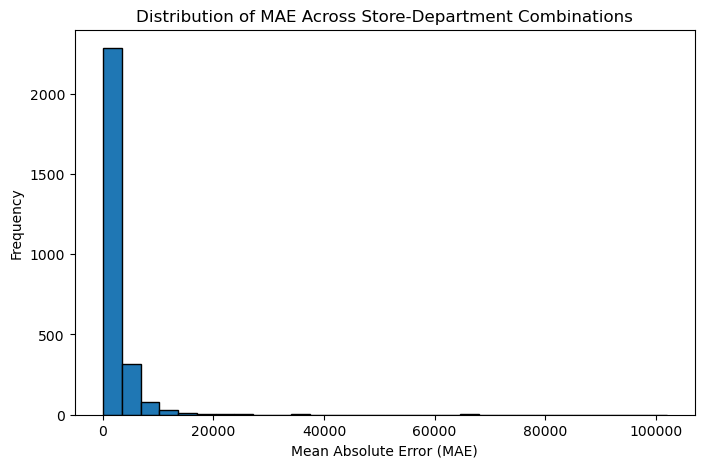

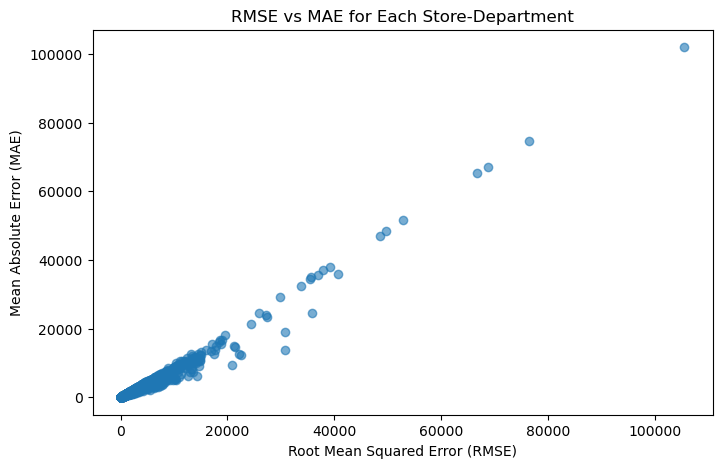

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings("ignore")

df = df[df["Weekly_Sales"] > 0]

df = df.copy()
df['Date'] = pd.to_datetime(df['Date(Date&Time)']) 
df = df.sort_values(by=['Store', 'Dept', 'Date(Date&Time)'])

forecast_periods = 52  # Weekly seasonality

evaluation_results = []

grouped = df.groupby(['Store', 'Dept'])

for (store, department), group in grouped:
    try:
        if len(group) > 2 * forecast_periods:
            train_size = int(0.8 * len(group))
            train, test = group.iloc[:train_size], group.iloc[train_size:]

            model = ExponentialSmoothing(
                train['Weekly_Sales'],
                trend='add',
                seasonal='add',
                seasonal_periods=forecast_periods
            )
            fit = model.fit()

            forecast = fit.forecast(len(test))

            mae = mean_absolute_error(test['Weekly_Sales'], forecast)
            rmse = np.sqrt(mean_squared_error(test['Weekly_Sales'], forecast))

            evaluation_results.append([store, department, mae, rmse])
        else:
            print(f"Skipped Store {store}, Department {department} due to insufficient data")

    except Exception as e:
        print(f"Error processing Store {store}, Department {department}: {e}")
        continue

metrics_df = pd.DataFrame(evaluation_results, columns=['Store', 'Department', 'MAE', 'RMSE'])

overall_mae = metrics_df['MAE'].mean()
overall_rmse = metrics_df['RMSE'].mean()

overall_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [overall_mae, overall_rmse]
})

print("\nOverall Forecast Error Metrics (Holt-Winters Model - Out-of-Sample):")
print(overall_metrics_df)

print("\nStore-Department Level Forecast Metrics (Out-of-Sample):")
print(metrics_df.head())

from IPython.display import display
display(overall_metrics_df)
display(metrics_df)

plt.figure(figsize=(8, 5))
plt.hist(metrics_df['MAE'], bins=30, edgecolor='black')
plt.xlabel('Mean Absolute Error (MAE)')
plt.ylabel('Frequency')
plt.title('Distribution of MAE Across Store-Department Combinations')
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(metrics_df['RMSE'], metrics_df['MAE'], alpha=0.6)
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('RMSE vs MAE for Each Store-Department')
plt.show()


In [ ]:
#CATEGORY TO RUN

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

df = df[df["Weekly_Sales"] > 0]

df = df.copy()
df['Date'] = pd.to_datetime(df['Date(Date&Time)']) 
df = df.sort_values(by=['Store', 'Dept_Category', 'Date(Date&Time)'])

forecast_periods = 52  # Weekly seasonality

evaluation_results = []

grouped = df.groupby(['Store', 'Dept_Category'])

for (store, category), group in grouped:
    try:
        if len(group) > 2 * forecast_periods:
            train_size = int(0.8 * len(group))
            train, test = group.iloc[:train_size], group.iloc[train_size:]

            model = ExponentialSmoothing(
                train['Weekly_Sales'],
                trend='add',
                seasonal='add',
                seasonal_periods=forecast_periods
            )
            fit = model.fit()

            forecast = fit.forecast(len(test))

            mae = mean_absolute_error(test['Weekly_Sales'], forecast)
            rmse = np.sqrt(mean_squared_error(test['Weekly_Sales'], forecast))

            evaluation_results.append([store, category, mae, rmse])
        else:
            print(f"Skipped Store {store}, Category {category} due to insufficient data")

    except Exception as e:
        print(f"Error processing Store {store}, Category {category}: {e}")
        continue

metrics_df = pd.DataFrame(evaluation_results, columns=['Store', 'Category', 'MAE', 'RMSE'])

overall_mae = metrics_df['MAE'].mean()
overall_rmse = metrics_df['RMSE'].mean()

overall_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [overall_mae, overall_rmse]
})

print("\nOverall Forecast Error Metrics (Holt-Winters Model - Store-Category Level):")
print(overall_metrics_df)

print("\nStore-Category Level Forecast Metrics (Out-of-Sample):")
print(metrics_df.head())

from IPython.display import display
display(overall_metrics_df)
display(metrics_df)

plt.figure(figsize=(8, 5))
plt.hist(metrics_df['MAE'], bins=30, edgecolor='black')
plt.xlabel('Mean Absolute Error (MAE)')
plt.ylabel('Frequency')
plt.title('Distribution of MAE Across Store-Category Combinations')
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(metrics_df['RMSE'], metrics_df['MAE'], alpha=0.6)
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('RMSE vs MAE for Each Store-Category')
plt.show()


## 2.2 ARIMA family


### 2.2.1 ARIMA

Skipping Store 1.0, Dept 77 (too few data points)
Skipping Store 1.0, Dept 78 (too few data points)
Skipping Store 2.0, Dept 39 (too few data points)
Skipping Store 2.0, Dept 77 (too few data points)
Skipping Store 3.0, Dept 47 (too few data points)
Skipping Store 3.0, Dept 77 (too few data points)
Skipping Store 3.0, Dept 78 (too few data points)
Skipping Store 3.0, Dept 83 (too few data points)
Skipping Store 4.0, Dept 39 (too few data points)
Skipping Store 4.0, Dept 47 (too few data points)
Skipping Store 4.0, Dept 77 (too few data points)
Skipping Store 4.0, Dept 78 (too few data points)
Skipping Store 5.0, Dept 47 (too few data points)
Skipping Store 5.0, Dept 51 (too few data points)
Skipping Store 5.0, Dept 77 (too few data points)
Skipping Store 5.0, Dept 78 (too few data points)
Skipping Store 5.0, Dept 80 (too few data points)
Skipping Store 6.0, Dept 47 (too few data points)
Skipping Store 6.0, Dept 51 (too few data points)
Skipping Store 6.0, Dept 77 (too few data points)


,Metric,Value
0,MAE,2272.648684
1,RMSE,2787.482773


,Store,Department,p,d,q,MAE,RMSE
0,1.0,1,2,0,0,5766.277978,6403.656790
1,1.0,2,1,0,0,1877.602492,2337.374846
2,1.0,3,2,0,0,7089.039740,11416.964281
3,1.0,4,0,0,4,2154.630428,2746.889323
4,1.0,5,2,0,0,5796.267585,6544.022757
...,...,...,...,...,...,...,...
3132,45.0,93,2,1,2,1536.543295,1807.577184
3133,45.0,94,1,1,1,1142.336745,1345.951625
3134,45.0,95,1,0,1,3022.775142,3973.843301
3135,45.0,97,1,0,3,466.835965,599.541225


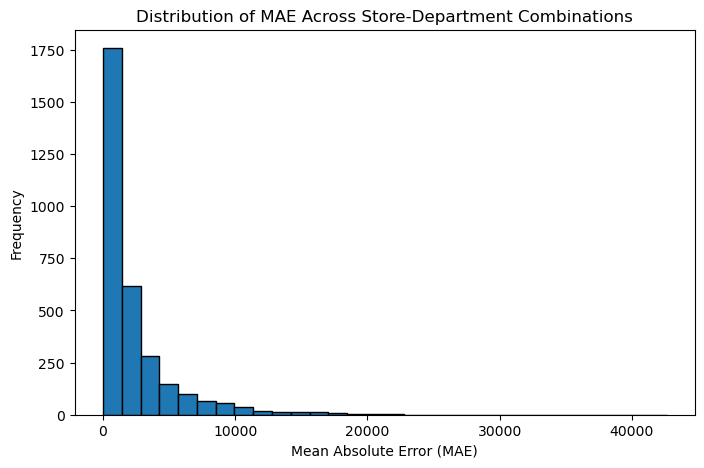

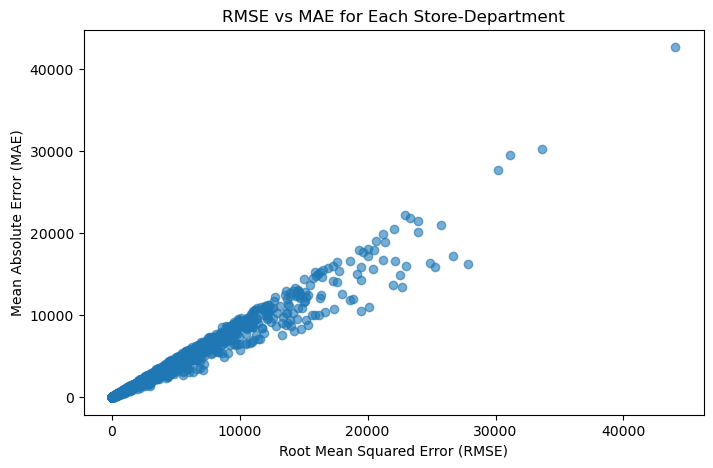

In [49]:

import warnings #10
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima

warnings.filterwarnings("ignore")

df = df[df["Weekly_Sales"] > 0]

evaluation_results = []

grouped = df.groupby(['Store', 'Dept'])

for (store, department), group in grouped:
    try:
        if len(group) < 10:
            print(f"Skipping Store {store}, Dept {department} (too few data points)")
            continue

        group = group.sort_values('Date(Date&Time)').reset_index(drop=True)

        train_size = int(0.8 * len(group))
        train, test = group.iloc[:train_size], group.iloc[train_size:]

        # ulteriore filtro per evitare Weekly_Sales negative o zero nel test
        test = test[test['Weekly_Sales'] > 0]
        if len(test) == 0:
            print(f"Skipping Store {store}, Dept {department} (no valid test data after filtering)")
            continue

        auto_model = auto_arima(train['Weekly_Sales'], seasonal=False, trace=False, 
                                error_action='ignore', suppress_warnings=True)
        p, d, q = auto_model.order

        model = ARIMA(train['Weekly_Sales'], order=(p, d, q))
        fit = model.fit()

        forecast = fit.forecast(steps=len(test))

        mae = mean_absolute_error(test['Weekly_Sales'], forecast)
        rmse = np.sqrt(mean_squared_error(test['Weekly_Sales'], forecast))

        evaluation_results.append([store, department, p, d, q, mae, rmse])

    except Exception as e:
        print(f"Error with Store {store}, Dept {department}: {e}")
        continue

metrics_df = pd.DataFrame(evaluation_results, columns=['Store', 'Department', 'p', 'd', 'q', 'MAE', 'RMSE'])

overall_mae = metrics_df['MAE'].mean()
overall_rmse = metrics_df['RMSE'].mean()

overall_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [overall_mae, overall_rmse]
})

print("\nOverall Forecast Error Metrics (ARIMA - Out-of-Sample):")
print(overall_metrics_df)

print("\nStore-Department Level Forecast Metrics (Out-of-Sample):")
print(metrics_df.head())

from IPython.display import display
display(overall_metrics_df)
display(metrics_df)

# Visualization - Histogram of MAE
plt.figure(figsize=(8, 5))
plt.hist(metrics_df['MAE'], bins=30, edgecolor='black')
plt.xlabel('Mean Absolute Error (MAE)')
plt.ylabel('Frequency')
plt.title('Distribution of MAE Across Store-Department Combinations')
plt.show()

# Visualization - Scatter plot of RMSE vs MAE
plt.figure(figsize=(8, 5))
plt.scatter(metrics_df['RMSE'], metrics_df['MAE'], alpha=0.6)
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('RMSE vs MAE for Each Store-Department')
plt.show()


Skipping Store 1.0, Dept 47 (too few data points)
Skipping Store 1.0, Dept 77 (too few data points)
Skipping Store 1.0, Dept 78 (too few data points)
Skipping Store 2.0, Dept 39 (too few data points)
Skipping Store 2.0, Dept 47 (too few data points)
Skipping Store 2.0, Dept 51 (too few data points)
Skipping Store 2.0, Dept 77 (too few data points)
Skipping Store 2.0, Dept 78 (too few data points)
Skipping Store 3.0, Dept 45 (too few data points)
Skipping Store 3.0, Dept 47 (too few data points)
Skipping Store 3.0, Dept 77 (too few data points)
Skipping Store 3.0, Dept 78 (too few data points)
Skipping Store 3.0, Dept 83 (too few data points)
Skipping Store 4.0, Dept 39 (too few data points)
Skipping Store 4.0, Dept 47 (too few data points)
Skipping Store 4.0, Dept 77 (too few data points)
Skipping Store 4.0, Dept 78 (too few data points)
Skipping Store 5.0, Dept 47 (too few data points)
Skipping Store 5.0, Dept 51 (too few data points)
Skipping Store 5.0, Dept 77 (too few data points)


,Metric,Value
0,MAE,2321.227056
1,RMSE,2847.162792


,Store,Department,p,d,q,MAE,RMSE
0,1.0,1,2,0,0,5766.277978,6403.656790
1,1.0,2,1,0,0,1877.602492,2337.374846
2,1.0,3,2,0,0,7089.039740,11416.964281
3,1.0,4,0,0,4,2154.630428,2746.889323
4,1.0,5,2,0,0,5796.267585,6544.022757
...,...,...,...,...,...,...,...
3065,45.0,93,2,1,2,1536.543295,1807.577184
3066,45.0,94,1,1,1,1142.336745,1345.951625
3067,45.0,95,1,0,1,3022.775142,3973.843301
3068,45.0,97,1,0,3,466.835965,599.541225


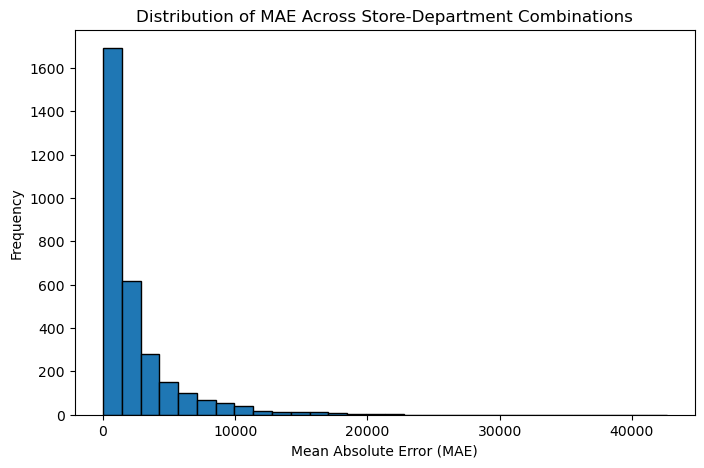

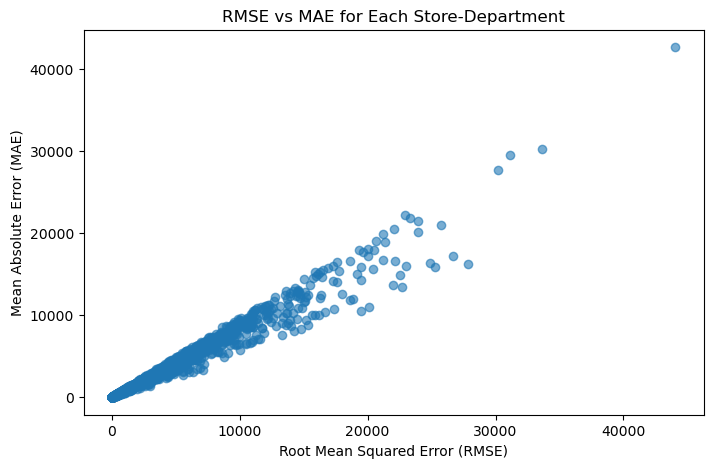

In [66]:

import warnings #20
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima

warnings.filterwarnings("ignore")

df = df[df["Weekly_Sales"] > 0]

evaluation_results = []

grouped = df.groupby(['Store', 'Dept'])

for (store, department), group in grouped:
    try:
        if len(group) < 20:
            print(f"Skipping Store {store}, Dept {department} (too few data points)")
            continue

        group = group.sort_values('Date(Date&Time)').reset_index(drop=True)

        train_size = int(0.8 * len(group))
        train, test = group.iloc[:train_size], group.iloc[train_size:]

        # ulteriore filtro per evitare Weekly_Sales negative o zero nel test
        test = test[test['Weekly_Sales'] > 0]
        if len(test) == 0:
            print(f"Skipping Store {store}, Dept {department} (no valid test data after filtering)")
            continue

        auto_model = auto_arima(train['Weekly_Sales'], seasonal=False, trace=False, 
                                error_action='ignore', suppress_warnings=True)
        p, d, q = auto_model.order

        model = ARIMA(train['Weekly_Sales'], order=(p, d, q))
        fit = model.fit()

        forecast = fit.forecast(steps=len(test))

        mae = mean_absolute_error(test['Weekly_Sales'], forecast)
        rmse = np.sqrt(mean_squared_error(test['Weekly_Sales'], forecast))

        evaluation_results.append([store, department, p, d, q, mae, rmse])

    except Exception as e:
        print(f"Error with Store {store}, Dept {department}: {e}")
        continue

metrics_df = pd.DataFrame(evaluation_results, columns=['Store', 'Department', 'p', 'd', 'q', 'MAE', 'RMSE'])

overall_mae = metrics_df['MAE'].mean()
overall_rmse = metrics_df['RMSE'].mean()

overall_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [overall_mae, overall_rmse]
})

print("\nOverall Forecast Error Metrics (ARIMA - Out-of-Sample):")
print(overall_metrics_df)

print("\nStore-Department Level Forecast Metrics (Out-of-Sample):")
print(metrics_df.head())

from IPython.display import display
display(overall_metrics_df)
display(metrics_df)

# Visualization - Histogram of MAE
plt.figure(figsize=(8, 5))
plt.hist(metrics_df['MAE'], bins=30, edgecolor='black')
plt.xlabel('Mean Absolute Error (MAE)')
plt.ylabel('Frequency')
plt.title('Distribution of MAE Across Store-Department Combinations')
plt.show()

# Visualization - Scatter plot of RMSE vs MAE
plt.figure(figsize=(8, 5))
plt.scatter(metrics_df['RMSE'], metrics_df['MAE'], alpha=0.6)
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('RMSE vs MAE for Each Store-Department')
plt.show()


### 2.2.2 SARIMAX 

Auto-ARIMA on Store 35.0, Dept 46.0
Auto-ARIMA on Store 7.0, Dept 3.0
Auto-ARIMA on Store 2.0, Dept 27.0
Auto-ARIMA on Store 41.0, Dept 52.0
Auto-ARIMA on Store 15.0, Dept 79.0
Auto-ARIMA on Store 14.0, Dept 17.0
Auto-ARIMA on Store 13.0, Dept 6.0
Auto-ARIMA on Store 8.0, Dept 45.0
 Auto-ARIMA failed on Store 8.0, Dept 45.0: There are no more samples after a first-order seasonal differencing. See http://alkaline-ml.com/pmdarima/seasonal-differencing-issues.html for a more in-depth explanation and potential work-arounds.
Auto-ARIMA on Store 41.0, Dept 28.0
Auto-ARIMA on Store 6.0, Dept 46.0

Computed SARIMAX parameters: p=1, d=0, q=1, P=1, D=0, Q=1, m=52


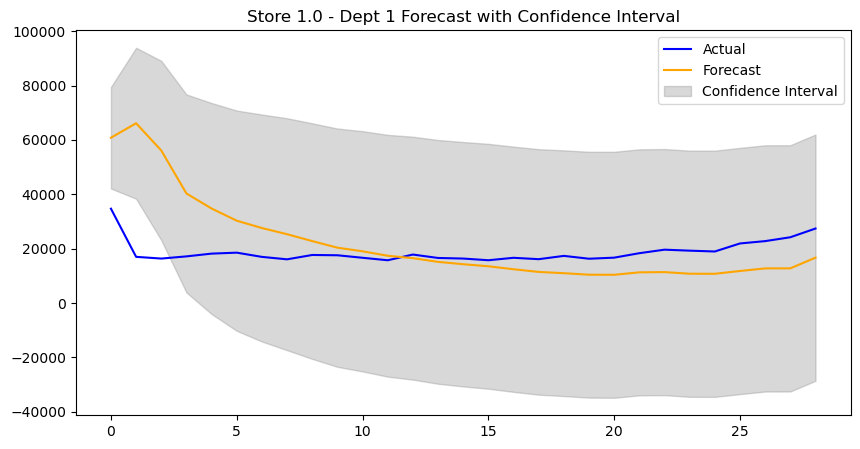

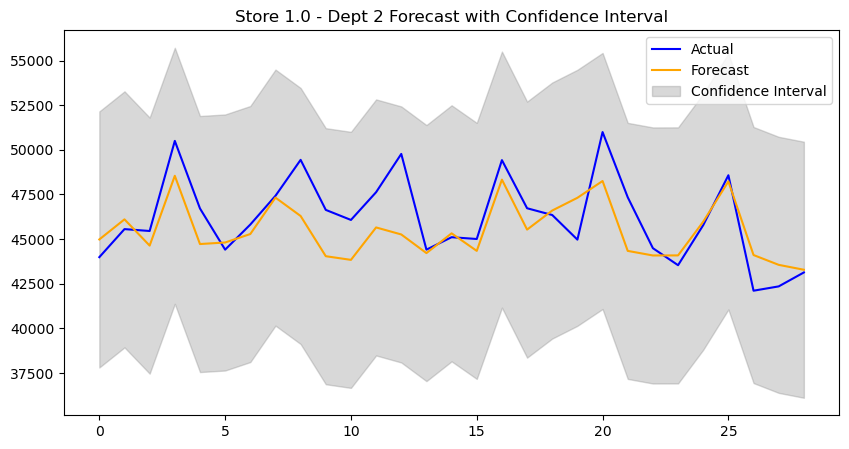

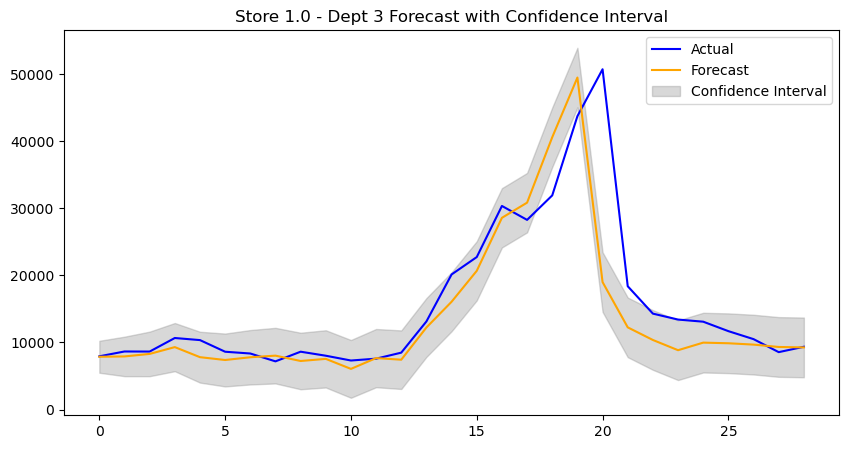

 Skipping Store 1.0, Dept 47 (too few data points)
 Skipping Store 1.0, Dept 77 (too few data points)
 Skipping Store 1.0, Dept 78 (too few data points)
 Skipping Store 2.0, Dept 39 (too few data points)
 Skipping Store 2.0, Dept 47 (too few data points)
 Skipping Store 2.0, Dept 51 (too few data points)
 Skipping Store 2.0, Dept 77 (too few data points)
 Skipping Store 2.0, Dept 78 (too few data points)
 Skipping Store 3.0, Dept 45 (too few data points)
 Skipping Store 3.0, Dept 47 (too few data points)
 Skipping Store 3.0, Dept 77 (too few data points)
 Skipping Store 3.0, Dept 78 (too few data points)
 Skipping Store 3.0, Dept 83 (too few data points)
 Skipping Store 4.0, Dept 39 (too few data points)
 Skipping Store 4.0, Dept 47 (too few data points)
 Skipping Store 4.0, Dept 77 (too few data points)
 Skipping Store 4.0, Dept 78 (too few data points)
Error on Store 5.0, Dept 9: LU decomposition error.
 Skipping Store 5.0, Dept 47 (too few data points)
 Skipping Store 5.0, Dept 51 (

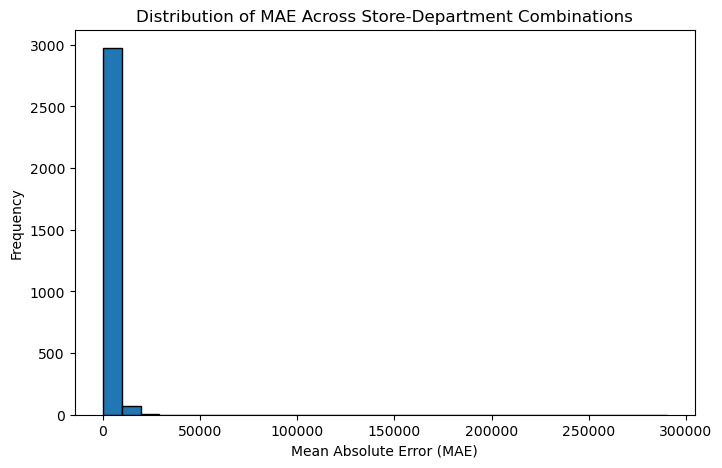

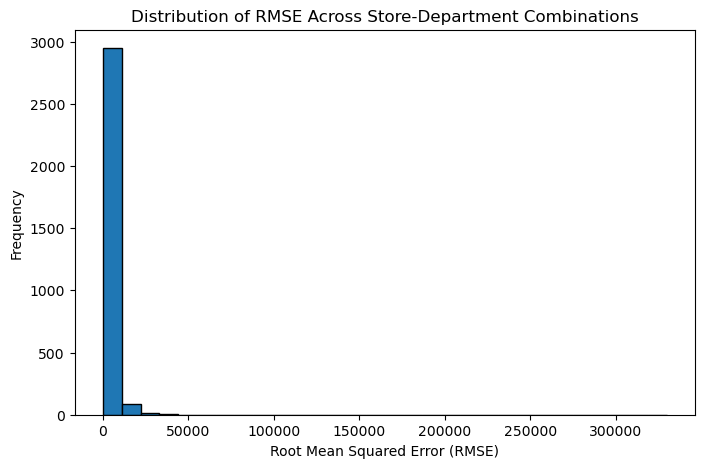

In [50]:
import warnings #20
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima
import random

warnings.filterwarnings("ignore")

# Filter out records with non-positive sales
df = df[df["Weekly_Sales"] > 0].copy()

evaluation_results = []

grouped = df.groupby(['Store', 'Dept'])
random.seed(42)

# Extract unique store-department pairs and randomly sample 10 for parameter tuning
unique_pairs = df[['Store', 'Dept']].drop_duplicates().values.tolist()
random_sample = random.sample(unique_pairs, 10)

orders = []
seasonal_orders = []

# Auto ARIMA on a sample of store-department pairs to compute average model parameters
for store, dept in random_sample:
    sample_data = df[(df['Store'] == store) & (df['Dept'] == dept)].sort_values('Date(Date&Time)')
    print(f"Auto-ARIMA on Store {store}, Dept {dept}")
    try:
        auto_model = auto_arima(
            sample_data['Weekly_Sales'],
            seasonal=True,
            m=52,  # Weekly seasonality
            trace=False,
            error_action='ignore',
            suppress_warnings=True,
            random_state=42
        )
        orders.append(auto_model.order)
        seasonal_orders.append(auto_model.seasonal_order)
    except Exception as e:
        print(f" Auto-ARIMA failed on Store {store}, Dept {dept}: {e}")

# Compute average SARIMAX parameters across the sample
p, d, q = np.array(orders).mean(axis=0).round().astype(int)
P, D, Q, m = np.array(seasonal_orders).mean(axis=0).round().astype(int)
print(f"\nComputed SARIMAX parameters: p={p}, d={d}, q={q}, P={P}, D={D}, Q={Q}, m={m}")

# Apply the model to each store-department pair using train-test split
for (store, department), group in grouped:
    try:
        if len(group) < 20:
            print(f" Skipping Store {store}, Dept {department} (too few data points)")
            continue

        group = group.sort_values('Date(Date&Time)').reset_index(drop=True)
        train_size = int(0.8 * len(group))
        train, test = group.iloc[:train_size], group.iloc[train_size:]

        # Fit SARIMAX on the training set
        model = SARIMAX(train['Weekly_Sales'], order=(p, d, q), seasonal_order=(P, D, Q, m))
        fit = model.fit(disp=False)

        # Forecast the test set with confidence intervals
        pred = fit.get_forecast(steps=len(test))
        forecast = pred.predicted_mean
        conf_int = pred.conf_int()

        # Compute out-of-sample error metrics
        mae = mean_absolute_error(test['Weekly_Sales'], forecast)
        rmse = np.sqrt(mean_squared_error(test['Weekly_Sales'], forecast))

        evaluation_results.append([store, department, mae, rmse])

        # Plot the forecast with confidence intervals for the first three store-department pairs
        if len(evaluation_results) <= 3:
            plt.figure(figsize=(10, 5))
            plt.plot(test['Weekly_Sales'].reset_index(drop=True), label='Actual', color='blue')
            plt.plot(forecast.reset_index(drop=True), label='Forecast', color='orange')
            plt.fill_between(np.arange(len(forecast)),
                             conf_int.iloc[:, 0].reset_index(drop=True),
                             conf_int.iloc[:, 1].reset_index(drop=True),
                             color='gray', alpha=0.3, label='Confidence Interval')
            plt.title(f'Store {store} - Dept {department} Forecast with Confidence Interval')
            plt.legend()
            plt.show()

    except Exception as e:
        print(f"Error on Store {store}, Dept {department}: {e}")
        continue

# Store-Department level metrics
metrics_df = pd.DataFrame(evaluation_results, columns=['Store', 'Department', 'MAE', 'RMSE'])

# Compute overall average metrics
overall_mae = metrics_df['MAE'].mean()
overall_rmse = metrics_df['RMSE'].mean()

overall_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [overall_mae, overall_rmse]
})

print("\nOverall Forecast Error Metrics (SARIMAX - Out-of-Sample):")
print(overall_metrics_df)

# Plot distribution of MAE across store-department combinations
plt.figure(figsize=(8, 5))
plt.hist(metrics_df['MAE'], bins=30, edgecolor='black')
plt.xlabel('Mean Absolute Error (MAE)')
plt.ylabel('Frequency')
plt.title('Distribution of MAE Across Store-Department Combinations')
plt.show()

# Plot distribution of RMSE across store-department combinations
plt.figure(figsize=(8, 5))
plt.hist(metrics_df['RMSE'], bins=30, edgecolor='black')
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Frequency')
plt.title('Distribution of RMSE Across Store-Department Combinations')
plt.show()


## PROPHET

In [10]:
!pip install prophet
from prophet import Prophet

Skipping Store 1.0, Dept 47 (too few data points)
Skipping Store 1.0, Dept 77 (too few data points)
Skipping Store 1.0, Dept 78 (too few data points)
Skipping Store 2.0, Dept 39 (too few data points)
Skipping Store 2.0, Dept 47 (too few data points)
Skipping Store 2.0, Dept 51 (too few data points)
Skipping Store 2.0, Dept 77 (too few data points)
Skipping Store 2.0, Dept 78 (too few data points)
Skipping Store 3.0, Dept 45 (too few data points)
Skipping Store 3.0, Dept 47 (too few data points)
Skipping Store 3.0, Dept 77 (too few data points)
Skipping Store 3.0, Dept 78 (too few data points)
Skipping Store 3.0, Dept 83 (too few data points)
Skipping Store 4.0, Dept 39 (too few data points)
Skipping Store 4.0, Dept 47 (too few data points)
Skipping Store 4.0, Dept 77 (too few data points)
Skipping Store 4.0, Dept 78 (too few data points)
Skipping Store 5.0, Dept 47 (too few data points)
Skipping Store 5.0, Dept 51 (too few data points)
Skipping Store 5.0, Dept 77 (too few data points)


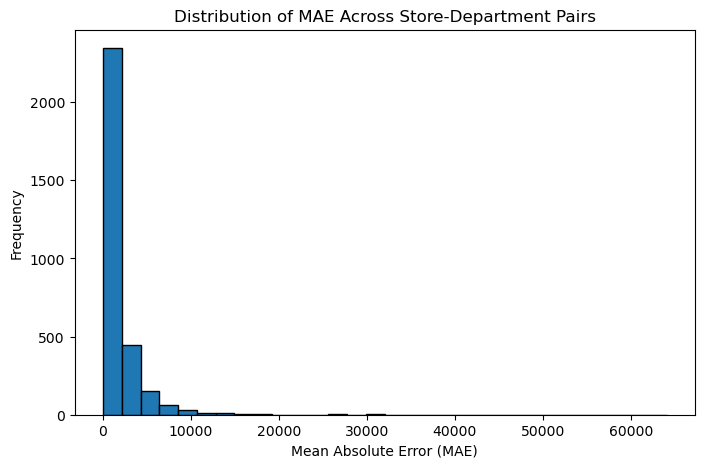

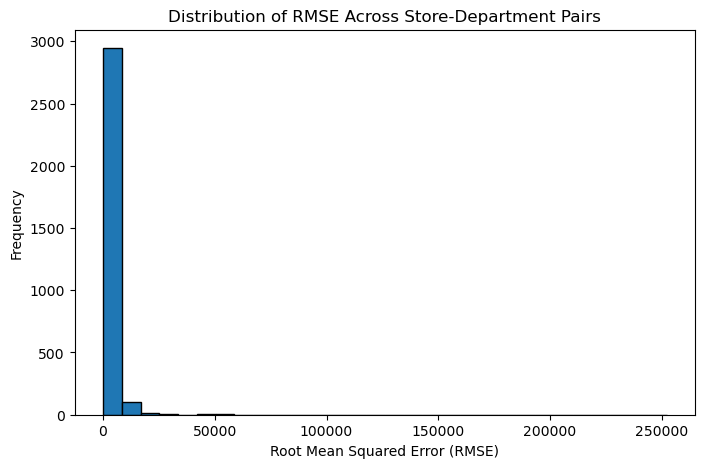

In [51]:
# PROPHET NO REGRESSORS - CLEAN VERSION WITH MAE and RMSE PLOTS (20) 

import numpy as np
import pandas as pd
import warnings
import logging
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet

logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
warnings.filterwarnings("ignore")

# Convert date column to datetime format
df['Date(Date&Time)'] = pd.to_datetime(df['Date(Date&Time)'])

# Filter out records with non-positive sales
df = df[df["Weekly_Sales"] > 0].copy()

evaluation_results = []

# Group by Store and Department
grouped = df.groupby(['Store', 'Dept'])

for (store, department), group in grouped:
    try:
        # Skip groups with insufficient data
        if len(group) < 20:
            print(f"Skipping Store {store}, Dept {department} (too few data points)")
            continue

        # Sort by date
        group = group.sort_values('Date(Date&Time)').reset_index(drop=True)

        # Train-test split (80% train, 20% test)
        train_size = int(0.8 * len(group))
        train, test = group.iloc[:train_size], group.iloc[train_size:]

        # Prepare data for Prophet
        train_df = train[['Date(Date&Time)', 'Weekly_Sales']].rename(columns={'Date(Date&Time)': 'ds', 'Weekly_Sales': 'y'})

        # Fit Prophet model on training data
        model = Prophet()
        model.fit(train_df)

        # Prepare test DataFrame for forecasting
        future = test[['Date(Date&Time)']].rename(columns={'Date(Date&Time)': 'ds'})

        # Forecast for the test period
        forecast = model.predict(future)

        # Compute error metrics
        y_true = test['Weekly_Sales'].values
        y_pred = forecast['yhat'].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        evaluation_results.append([store, department, mae, rmse])

    except Exception as e:
        print(f"Error with Store {store}, Dept {department}: {e}")
        continue

# Create a DataFrame with the evaluation results
metrics_df = pd.DataFrame(evaluation_results, columns=['Store', 'Department', 'MAE', 'RMSE'])

# Compute overall error metrics as the mean across groups
overall_mae = metrics_df['MAE'].mean()
overall_rmse = metrics_df['RMSE'].mean()

overall_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [overall_mae, overall_rmse]
})

print("\nEvaluation metrics by Store and Department (Out-of-Sample):")
print(metrics_df.head())

print("\nOverall Metrics across all Store-Department pairs (Out-of-Sample):")
print(overall_metrics_df)

# Plot the distribution of MAE across Store-Department pairs
plt.figure(figsize=(8, 5))
plt.hist(metrics_df['MAE'], bins=30, edgecolor='black')
plt.xlabel('Mean Absolute Error (MAE)')
plt.ylabel('Frequency')
plt.title('Distribution of MAE Across Store-Department Pairs')
plt.show()

# Plot the distribution of RMSE across Store-Department pairs
plt.figure(figsize=(8, 5))
plt.hist(metrics_df['RMSE'], bins=30, edgecolor='black')
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Frequency')
plt.title('Distribution of RMSE Across Store-Department Pairs')
plt.show()



Evaluation metrics by Store and Department (Out-of-Sample):
   Store  Department          MAE         RMSE
0    1.0           1  8246.631689  9122.881511
1    1.0           2  4066.731498  4585.164894
2    1.0           3  3579.001467  5280.638837
3    1.0           4  2636.089750  3198.715931
4    1.0           5  4521.828253  5761.029545

Overall Metrics across all Store-Department pairs (Out-of-Sample):
  Metric        Value
0    MAE  2364.696643
1   RMSE  3081.485721


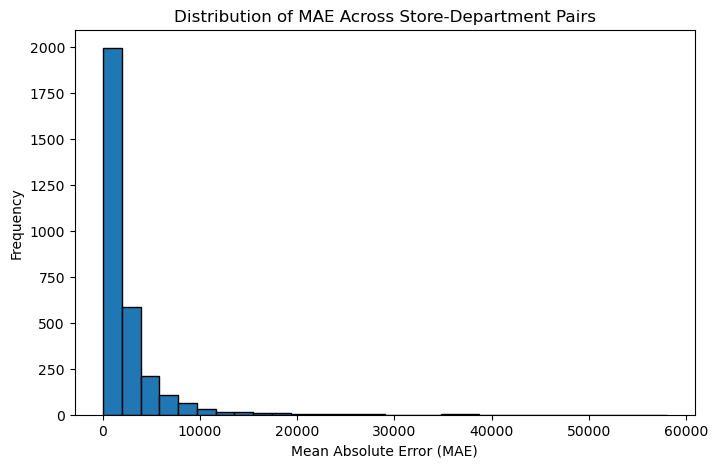

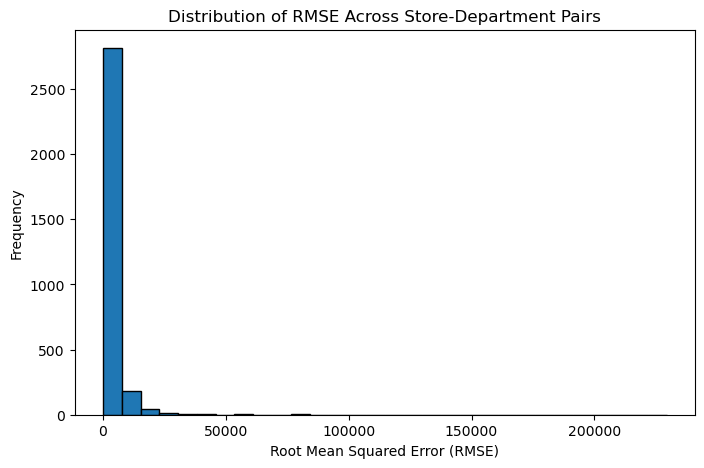

In [67]:
# PROPHET WITH SCALED REGRESSORS - CLEAN VERSION WITH MAE AND RMSE PLOTS (20)  to add 

import warnings
import logging
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from prophet import Prophet

logging.getLogger('cmdstanpy').setLevel(logging.CRITICAL)
warnings.filterwarnings("ignore")

# Filter out records with non-positive sales
df = df[df["Weekly_Sales"] > 0].copy()
continuous_vars = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size', 'AMD1', 'AMD2']

evaluation_results = []

# Group data by Store and Department
grouped = df.groupby(['Store', 'Dept'])

for (store, department), group in grouped:
    try:
        if len(group) < 20:
            continue

        # Sort the group by date
        group = group.sort_values('Date(Date&Time)').reset_index(drop=True)

        # Train-test split (80% train, 20% test)
        train_size = int(0.8 * len(group))
        train, test = group.iloc[:train_size], group.iloc[train_size:]

        # Scale continuous regressors based on the training set
        scaler = StandardScaler()
        train_scaled = train.copy()
        test_scaled = test.copy()

        scaler.fit(train[continuous_vars])
        train_scaled[continuous_vars] = scaler.transform(train[continuous_vars])
        test_scaled[continuous_vars] = scaler.transform(test[continuous_vars])

        # Prepare Prophet training DataFrame
        prophet_train = train_scaled[['Date(Date&Time)', 'Weekly_Sales', 'IsHoliday'] + continuous_vars]
        prophet_train = prophet_train.rename(columns={'Date(Date&Time)': 'ds', 'Weekly_Sales': 'y'})

        # Initialize Prophet model with external regressors
        model = Prophet()
        model.add_regressor('IsHoliday')
        for reg in continuous_vars:
            model.add_regressor(reg)

        model.fit(prophet_train)

        # Prepare test DataFrame for prediction
        prophet_test = test_scaled[['Date(Date&Time)', 'IsHoliday'] + continuous_vars]
        prophet_test = prophet_test.rename(columns={'Date(Date&Time)': 'ds'})

        # Forecast on the test set
        forecast = model.predict(prophet_test)

        # Compute out-of-sample error metrics
        y_true = test_scaled['Weekly_Sales'].values
        y_pred = forecast['yhat'].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        evaluation_results.append([store, department, mae, rmse])

    except Exception as e:
        print(f"Error in Store {store}, Dept {department}: {e}")
        continue

# Collect the evaluation results
metrics_df = pd.DataFrame(evaluation_results, columns=['Store', 'Department', 'MAE', 'RMSE'])

# Compute overall average metrics
overall_mae = metrics_df['MAE'].mean()
overall_rmse = metrics_df['RMSE'].mean()

overall_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [overall_mae, overall_rmse]
})

print("\nEvaluation metrics by Store and Department (Out-of-Sample):")
print(metrics_df.head())

print("\nOverall Metrics across all Store-Department pairs (Out-of-Sample):")
print(overall_metrics_df)

# Plot the distribution of MAE across Store-Department pairs
plt.figure(figsize=(8, 5))
plt.hist(metrics_df['MAE'], bins=30, edgecolor='black')
plt.xlabel('Mean Absolute Error (MAE)')
plt.ylabel('Frequency')
plt.title('Distribution of MAE Across Store-Department Pairs')
plt.show()

# Plot the distribution of RMSE across Store-Department pairs
plt.figure(figsize=(8, 5))
plt.hist(metrics_df['RMSE'], bins=30, edgecolor='black')
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Frequency')
plt.title('Distribution of RMSE Across Store-Department Pairs')
plt.show()



Evaluation metrics by Store and Department (Out-of-Sample):
   Store  Department          MAE         RMSE
0    1.0           1  2143.431079  3842.816190
1    1.0           2  2269.767678  2726.319030
2    1.0           3  2902.607970  4966.045284
3    1.0           4  1816.868676  2369.413452
4    1.0           5  2478.132778  3288.701586

Overall Metrics across all Store-Department pairs (Out-of-Sample):
  Metric        Value
0    MAE  1710.739593
1   RMSE  2313.816393


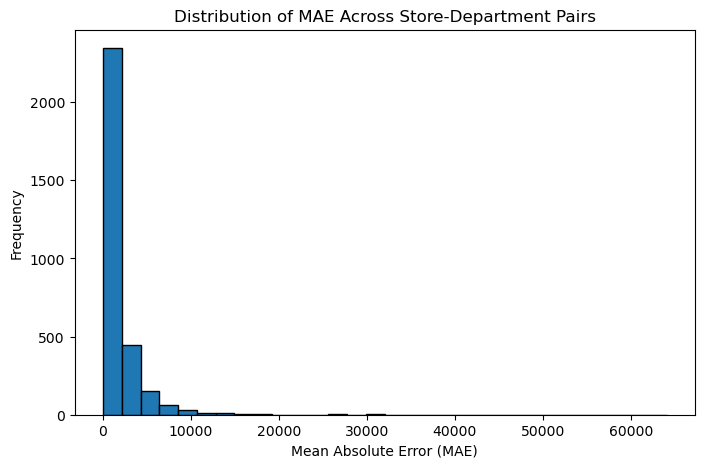

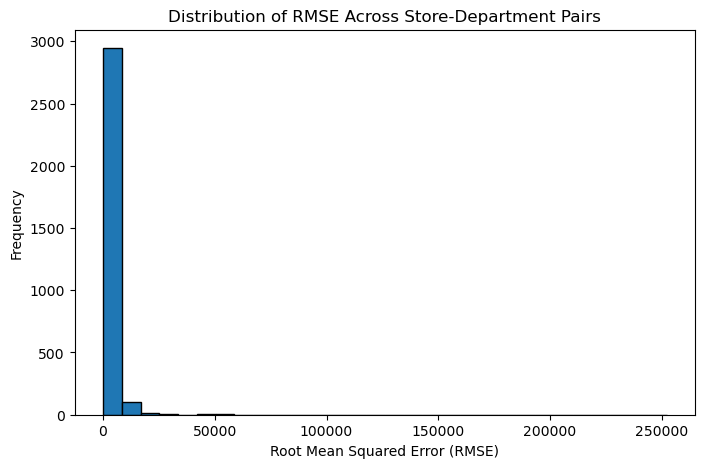

In [56]:
#ONLY SIZE AS REGRESSOR
import warnings
import logging
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from prophet import Prophet
import pandas as pd
import numpy as np

logging.getLogger('cmdstanpy').setLevel(logging.CRITICAL)
warnings.filterwarnings("ignore")

# Assumo che df sia già caricato e la colonna date sia già convertita in datetime
df = df[df["Weekly_Sales"] > 0].copy()

evaluation_results = []

# Group data by Store and Department
grouped = df.groupby(['Store', 'Dept'])

for (store, department), group in grouped:
    try:
        if len(group) < 20:
            continue

        # Sort the group by date
        group = group.sort_values('Date(Date&Time)').reset_index(drop=True)

        # Train-test split (80% train, 20% test)
        train_size = int(0.8 * len(group))
        train, test = group.iloc[:train_size], group.iloc[train_size:]

        # Scale 'Size' regressor based on the training set
        scaler = StandardScaler()
        train_scaled = train.copy()
        test_scaled = test.copy()

        scaler.fit(train[['Size']])
        train_scaled['Size'] = scaler.transform(train[['Size']])
        test_scaled['Size'] = scaler.transform(test[['Size']])

        # Prepare Prophet training DataFrame
        prophet_train = train_scaled[['Date(Date&Time)', 'Weekly_Sales', 'Size']]
        prophet_train = prophet_train.rename(columns={'Date(Date&Time)': 'ds', 'Weekly_Sales': 'y'})

        # Initialize Prophet model with 'Size' as regressor
        model = Prophet()
        model.add_regressor('Size')
        model.fit(prophet_train)

        # Prepare test DataFrame for prediction
        prophet_test = test_scaled[['Date(Date&Time)', 'Size']]
        prophet_test = prophet_test.rename(columns={'Date(Date&Time)': 'ds'})

        # Forecast on the test set
        forecast = model.predict(prophet_test)

        # Compute out-of-sample error metrics
        y_true = test_scaled['Weekly_Sales'].values
        y_pred = forecast['yhat'].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        evaluation_results.append([store, department, mae, rmse])

    except Exception as e:
        print(f"Error in Store {store}, Dept {department}: {e}")
        continue

# Collect the evaluation results
metrics_df = pd.DataFrame(evaluation_results, columns=['Store', 'Department', 'MAE', 'RMSE'])

# Compute overall average metrics
overall_mae = metrics_df['MAE'].mean()
overall_rmse = metrics_df['RMSE'].mean()

overall_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [overall_mae, overall_rmse]
})

print("\nEvaluation metrics by Store and Department (Out-of-Sample):")
print(metrics_df.head())

print("\nOverall Metrics across all Store-Department pairs (Out-of-Sample):")
print(overall_metrics_df)

# Plot the distribution of MAE across Store-Department pairs
plt.figure(figsize=(8, 5))
plt.hist(metrics_df['MAE'], bins=30, edgecolor='black')
plt.xlabel('Mean Absolute Error (MAE)')
plt.ylabel('Frequency')
plt.title('Distribution of MAE Across Store-Department Pairs')
plt.show()

# Plot the distribution of RMSE across Store-Department pairs
plt.figure(figsize=(8, 5))
plt.hist(metrics_df['RMSE'], bins=30, edgecolor='black')
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Frequency')
plt.title('Distribution of RMSE Across Store-Department Pairs')
plt.show()


15:35:25 - cmdstanpy - INFO - Chain [1] start processing
15:35:25 - cmdstanpy - INFO - Chain [1] done processing
15:35:25 - cmdstanpy - INFO - Chain [1] start processing
15:35:25 - cmdstanpy - INFO - Chain [1] done processing
15:35:26 - cmdstanpy - INFO - Chain [1] start processing
15:35:26 - cmdstanpy - INFO - Chain [1] done processing
15:35:26 - cmdstanpy - INFO - Chain [1] start processing
15:35:26 - cmdstanpy - INFO - Chain [1] done processing
15:35:26 - cmdstanpy - INFO - Chain [1] start processing
15:35:26 - cmdstanpy - INFO - Chain [1] done processing
15:35:27 - cmdstanpy - INFO - Chain [1] start processing
15:35:27 - cmdstanpy - INFO - Chain [1] done processing
15:35:27 - cmdstanpy - INFO - Chain [1] start processing
15:35:27 - cmdstanpy - INFO - Chain [1] done processing
15:35:27 - cmdstanpy - INFO - Chain [1] start processing
15:35:27 - cmdstanpy - INFO - Chain [1] done processing
15:35:28 - cmdstanpy - INFO - Chain [1] start processing
15:35:28 - cmdstanpy - INFO - Chain [1]


Evaluation metrics by Store and Department (Out-of-Sample):
   Store  Department          MAE         RMSE
0    1.0           1  8479.146436  9166.974092
1    1.0           2  6603.262839  7200.609194
2    1.0           3  4779.167490  6907.474383
3    1.0           4  3639.226846  4248.359567
4    1.0           5  4014.367071  5486.009837

Overall Metrics across all Store-Department pairs (Out-of-Sample):
  Metric        Value
0    MAE  2739.570496
1   RMSE  3417.446051


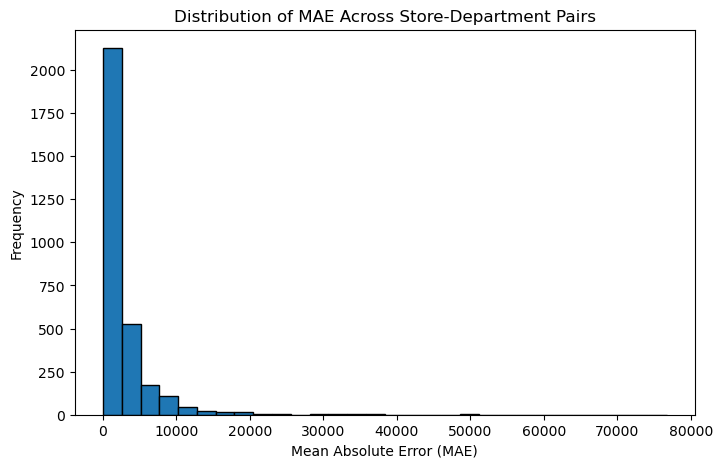

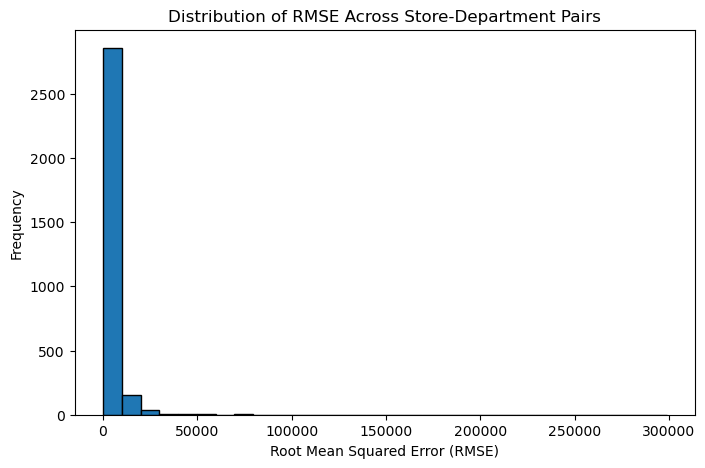

In [ ]:
import warnings #va peggio?????
import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from prophet import Prophet

logging.getLogger('cmdstanpy').setLevel(logging.CRITICAL)
warnings.filterwarnings("ignore")

# Filter out records with non-positive sales
df = df[df["Weekly_Sales"] > 0].copy()

# Define base regressors
continuous_vars = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size', 'AMD1', 'AMD2']
lag_vars = ['lag_1', 'lag_2']  # Define lag variable names
all_regressors = ['IsHoliday'] + continuous_vars + lag_vars

evaluation_results = []

# Group data by Store and Department
grouped = df.groupby(['Store', 'Dept'])

for (store, department), group in grouped:
    try:
        if len(group) < 20:
            continue

        # Sort the group by date
        group = group.sort_values('Date(Date&Time)').reset_index(drop=True)

        # Compute lag features
        group['lag_1'] = group['Weekly_Sales'].shift(1)
        group['lag_2'] = group['Weekly_Sales'].shift(2)

        # Drop rows with NaN due to lag creation
        group = group.dropna().reset_index(drop=True)
        if len(group) < 20:
            continue

        # Train-test split (80% train, 20% test)
        train_size = int(0.8 * len(group))
        train, test = group.iloc[:train_size], group.iloc[train_size:]

        # Scale continuous and lag regressors
        scaler = StandardScaler()
        train_scaled = train.copy()
        test_scaled = test.copy()

        scaler.fit(train[continuous_vars + lag_vars])
        train_scaled[continuous_vars + lag_vars] = scaler.transform(train[continuous_vars + lag_vars])
        test_scaled[continuous_vars + lag_vars] = scaler.transform(test[continuous_vars + lag_vars])

        # Prepare Prophet training DataFrame
        prophet_train = train_scaled[['Date(Date&Time)', 'Weekly_Sales'] + all_regressors]
        prophet_train = prophet_train.rename(columns={'Date(Date&Time)': 'ds', 'Weekly_Sales': 'y'})

        # Initialize Prophet model with regressors
        model = Prophet()
        for reg in all_regressors:
            model.add_regressor(reg)

        model.fit(prophet_train)

        # Prepare test DataFrame for prediction
        prophet_test = test_scaled[['Date(Date&Time)'] + all_regressors]
        prophet_test = prophet_test.rename(columns={'Date(Date&Time)': 'ds'})

        # Forecast on the test set
        forecast = model.predict(prophet_test)

        # Compute out-of-sample error metrics
        y_true = test_scaled['Weekly_Sales'].values
        y_pred = forecast['yhat'].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        evaluation_results.append([store, department, mae, rmse])

    except Exception as e:
        print(f"Error in Store {store}, Dept {department}: {e}")
        continue

# Collect the evaluation results
metrics_df = pd.DataFrame(evaluation_results, columns=['Store', 'Department', 'MAE', 'RMSE'])

# Compute overall average metrics
overall_mae = metrics_df['MAE'].mean()
overall_rmse = metrics_df['RMSE'].mean()

overall_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Value': [overall_mae, overall_rmse]
})

print("\nEvaluation metrics by Store and Department (Out-of-Sample):")
print(metrics_df.head())

print("\nOverall Metrics across all Store-Department pairs (Out-of-Sample):")
print(overall_metrics_df)

# Plot the distribution of MAE across Store-Department pairs
plt.figure(figsize=(8, 5))
plt.hist(metrics_df['MAE'], bins=30, edgecolor='black')
plt.xlabel('Mean Absolute Error (MAE)')
plt.ylabel('Frequency')
plt.title('Distribution of MAE Across Store-Department Pairs')
plt.show()

# Plot the distribution of RMSE across Store-Department pairs
plt.figure(figsize=(8, 5))
plt.hist(metrics_df['RMSE'], bins=30, edgecolor='black')
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Frequency')
plt.title('Distribution of RMSE Across Store-Department Pairs')
plt.show()
